**Proyecto:** Análisis de la Mortalidad Fetal Potencialmente Prevenible en   Ecuador mediante Clustering y Modelos de Clasificación para la Identificación de Perfiles de Vulnerabilidad Materna

---



**Antecedentes:**  En el entregable de la Semana 2 "1. S2_Izquierdo_Nicole_Capstone: Selección y Descripción Dataset" ya se realizó un proceso de limpieza y normalización del Dataset, el cual consistió en:

**1. Corrección de Codificación (BOM):** Se detectó la presencia de caracteres Byte Order Mark (ï»¿) en el encabezado del archivo original, los cuales fueron eliminados mediante la decodificación utf-8-sig para permitir el acceso correcto a la primera variable (prov_insc).

**2. Normalización de Metadatos:** Se aplicó una función de limpieza de espacios en blanco (stripping) a los nombres de las 43 variables para evitar errores de referencia en el diccionario de datos.

**3. Depuración de Registros Malformados:** Durante la carga, se descartaron registros con inconsistencias en los delimitadores (filas con exceso de columnas por errores de digitación en origen), resultando en una cantidad efectiva de 1.328 registros.

**4. Alineación con Diccionario ANDA-INEC:** Se vincularon las variables técnicas con sus descripciones oficiales para asegurar la trazabilidad institucional del estudio.

**5. Detección de Valores Atípicos**

Se identificaron las variables que presentan códigos de no respuesta, con el fin de determinar la estrategia de limpieza y evitar sesgos en el algoritmo de agrupamiento.

**6. Refinamiento por Criterio de Variables Críticas**

Dentro de las variables que presentan valores atípicos, se han identificado un conjunto de 7 variables críticas que representan el perfil socio-demográfico y clínico necesario para el modelado de vulnerabilidad: edad_mad, sem_gest, con_pren, niv_inst, sabe_leer, etnia y est_civil.

Para asegurar la precisión del algoritmo de Clustering, se opta por una depuración que consiste en la eliminación de los registros que presenten omisiones o falta de información en cualquiera de estas dimensiones.

Esto permite trabajar con datos de integridad elevada, evitando que valores nulos distorsionen la formación de los grupos de riesgo.

**7. Imputación de Variables Antropométricas**

Se han identificado 2 variales continuas (peso y talla) que presentan valores atípicos, se optó por una estrategia de imputación por mediana, esta decisión se fundamenta en la capacidad de la mediana para resistir la influencia de valores atípicos presentes en los registros de defunciones fetales.

Al mantener la tendencia central de la muestra, se preserva la integridad del volumen de datos sin sesgar las mediciones físicas que son críticas para la determinación de los clústeres de riesgo.

**8. Imputación de Variables de Antecedentes de Paridad**

Para las variables (hij_viv) e (hij_vivm), los registros identificados con la etiqueta "Sin información" fueron tratados mediante imputación por moda. Se selecciona esta técnica debido a que estas variables son de naturaleza discreta y presentan una distribución sesgada donde la mayoría de la población se concentra en un valor específico. Este procedimiento permite conservar la representatividad de la muestra sin introducir distorsiones significativas en el cálculo de distancias para el Clustering.

**9. Justificación de Variables Sin Intervención**

Se ha determinado no aplicar procesos de depuración, transformación o imputación sobre las variables (nac_mad) nacionalidad de la madre y (dia_mad) día de nacimiento de la madre debido a que estas dimensiones actúan como datos de registro civil y control de identidad, careciendo de una relación causal directa con la variabilidad biológica del fenómeno de mortalidad fetal en el contexto de este modelo de clustering, sin embargo, se optó por conservar estas variables en su estado original únicamente para fines de consulta o trazabilidad de los datos, garantizando que el espacio de características del modelo se concentre exclusivamente en factores clínicos y sociodemográficos de alto impacto.


---




**Consolidación del Dataset**

Tras completar el ciclo de preprocesamiento, se consolida el Dataset que constituye el universo total de la investigación, esta base de datos representa la totalidad de los registros depurados que cumplen con estándares de calidad adecuados

La eliminación de ruidos y la normalización garantizan que cualquier inferencia realizada sobre este universo sea estadísticamente sólida.

In [ ]:
# =========================
# 1. Importar librerías
# =========================
import pandas as pd
import numpy as np

# =========================
# 2. Selección de archivo
# =========================
from google.colab import files
uploaded = files.upload()

# =========================
# 3. Cargar el dataset
# =========================
df = pd.read_csv("dataset__limpio.csv")

# =========================
# 4. Cálculo de métricas
# =========================
n_registros = df.shape[0]
n_variables = df.shape[1]

total_celdas = n_registros * n_variables
celdas_no_nulas = df.notna().sum().sum()
indice_integridad = (celdas_no_nulas / total_celdas) * 100

# =========================
# 5. Tabla resumen
# =========================
resumen_dataset = pd.DataFrame({
    "Indicador": [
        "Universo total de registros (N)",
        "Número de variables",
        "Índice de integridad (%)"
    ],
    "Valor": [
        n_registros,
        n_variables,
        round(indice_integridad, 2)
    ]
})

# =========================
# 6. Mostrar tabla
# =========================
resumen_dataset


Saving dataset__limpio.csv to dataset__limpio (3).csv


,Indicador,Valor
0,Universo total de registros (N),1184.00
1,Número de variables,43.00
2,Índice de integridad (%),99.94


El dataset analizado cuenta con un universo total de 1.184 registros y 43 variables de análisis. El Índice de Integridad global (99.94%) evidencia un alto nivel de completitud de la información, lo que permite avanzar hacia las etapas de análisis.

---



**Integridad por Variable**

A continuación se presenta una tabla que muestra la integridad por cada una de las variables del Dataset

In [ ]:
import pandas as pd
from IPython.display import display, HTML

# =========================
# 1. Tabla base de variables
# =========================
tabla_variables = pd.DataFrame({
    "Variable": df.columns,
    "Tipo Original": df.dtypes.astype(str),
    "Registros totales": len(df),
    "Registros no nulos": df.notna().sum().values,
    "Registros nulos": df.isna().sum().values
})

tabla_variables["% Completitud"] = (
    tabla_variables["Registros no nulos"] / tabla_variables["Registros totales"] * 100
).round(2)

tabla_variables["% Missing"] = (
    tabla_variables["Registros nulos"] / tabla_variables["Registros totales"] * 100
).round(2)

# =========================
# 2. Clasificación de variables
# =========================
def clasificar(row):
    nom = row['Variable'].lower()
    tipo = row['Tipo Original']
    if 'fecha' in nom:
        return 'Temporal (Fecha)'
    elif any(x in nom for x in ['anio', 'mes', 'dia']):
        return 'Temporal (Componente)'
    elif 'int' in tipo:
        return 'Numérica (Discreta)'
    elif 'float' in tipo:
        return 'Numérica (Continua)'
    else:
        return 'Categórica (Cualitativa)'

tabla_variables['Tipo'] = tabla_variables.apply(clasificar, axis=1)

# =========================
# 3. Agregar descripción desde diccionario
# =========================
tabla_variables['Descripción'] = tabla_variables['Variable'].map(diccionario_completo)

# Reordenar columnas para mejor lectura
tabla_variables = tabla_variables[[
    'Variable',
    'Descripción',
    'Tipo Original',
    'Tipo',
    'Registros totales',
    'Registros no nulos',
    'Registros nulos',
    '% Completitud',
    '% Missing'
]]

# Ordenar por nivel de completitud
tabla_variables = tabla_variables.sort_values(
    by='% Completitud',
    ascending=True
).reset_index(drop=True)

# =========================
# 4. Estilo visual (centrado)
# =========================
estilo_tabla = """
<style>
    table {
        width: 100%;
        border-collapse: collapse;
    }
    th {
        background-color: #2c3e50;
        color: white;
        text-align: center !important;
        padding: 10px;
    }
    td {
        text-align: center !important;
        padding: 8px;
        border: 1px solid #ddd;
    }
    tr:nth-child(even) {background-color: #f2f2f2;}
    tr:hover {background-color: #ddd;}
</style>
"""

# =========================
# 5. Renderizar tabla final
# =========================
display(HTML(estilo_tabla + tabla_variables.to_html(index=False)))


Variable,Descripción,Tipo Original,Tipo,Registros totales,Registros no nulos,Registros nulos,% Completitud,% Missing
dia_mad,Día de nacimiento de la madre,float64,Temporal (Componente),1184,1154,30,97.47,2.53
nac_mad,Nacionalidad de la madre,object,Categórica (Cualitativa),1184,1183,1,99.92,0.08
prov_insc,Provincia donde se inscribe la defunción fetal,object,Categórica (Cualitativa),1184,1184,0,100.00,0.00
cant_insc,Cantón donde se inscribe la defunción fetal,object,Categórica (Cualitativa),1184,1184,0,100.00,0.00
mes_insc,Mes de inscripción de la defunción fetal,int64,Temporal (Componente),1184,1184,0,100.00,0.00
dia_insc,Día de inscripción de la defunción fetal,int64,Temporal (Componente),1184,1184,0,100.00,0.00
parr_insc,Parroquia donde se inscribe la defunción fetal,object,Categórica (Cualitativa),1184,1184,0,100.00,0.00
anio_insc,Año de inscripción de la defunción fetal,int64,Temporal (Componente),1184,1184,0,100.00,0.00
peso,Peso del feto (gramos a 4 dígitos),float64,Numérica (Continua),1184,1184,0,100.00,0.00
sem_gest,Semanas de gestación,int64,Numérica (Discreta),1184,1184,0,100.00,0.00


La clasificación de variables se realizó considerando tanto el tipo técnico del dato como su rol analítico, permitiendo diferenciar variables temporales, numéricas y categóricas de forma consistente con su uso posterior en análisis exploratorio y modelado.

---



**Subconjuntos y definición de variables de interés**

Para el desarrollo del análisis se identificaran variables clave, clasificadas según su rol dentro del modelo analítico, orientadas a capturar la desigualdad en el acceso a la salud y el riesgo reproductivo:

**Variables explicativas**

Incluyen dimensiones geográficas, biológicas, contextuales y de atención que actúan como determinantes del desenlace fetal.

**1. Variables Geográficas:** Identifican los nodos críticos de mortalidad y las brechas de infraestructura. El análisis del Área, urbana o rural, es fundamental para evidenciar la desigualdad, ya que las zonas rurales suelen presentar mayores barreras de acceso, deficiencias en el transporte y tiempos de traslado más prolongados hacia centros de especialidad.

El contraste entre el lugar de residencia y el de fallecimiento permite, además, inferir la lejanía como un factor de riesgo.

* Área de fallecimiento (area_fall)
* Provincia de fallecimiento (prov_fall)
* Cantón de fallecimiento (cant_fall)
* Parroquia de fallecimiento (parr_fall)
* Provincia de residencia de la madre (prov_res)
* Cantón de residencia de la madre (cant_res)
* Parroquia de residencia de la madre (parr_res)
* Área de residencia de la madre (area_res)


**2. Características Biológicas y de Desarrollo:** Estas variables permiten caracterizar la madurez física y la viabilidad del feto al momento del fallecimiento. Son indicadores directos del desarrollo intrauterino y actúan como señales de alerta sobre la salud de la madre y la efectividad de la vigilancia médica durante la gestación.

* Peso (peso)
* Talla (talla)
* Edad Gestacional (sem_gest)


**3. Determinantes de Acceso y Atención:** Miden la oportunidad y la calidad de la respuesta del sistema de salud ante el embarazo. El lugar de ocurrencia y la persona que atiende el evento reflejan el grado de institucionalización y profesionalización de la asistencia recibida, estos factores son determinantes en la evitabilidad del deceso.

* Número de Controles prenatales (con_pren)
* Persona que atendió el parto (asis_por)
* Causa que ocasionó la defunción fetal (causa_fetal)
* Lugar de ocurrencia (lugar_ocur)

**4. Factores de Vulnerabilidad Materna:** Representan el perfil sociodemográfico y educativo de la madre, estas variables son cruciales para entender cómo los determinantes sociales, nivel de instrucción, etnia o  condición de extranjería, condicionan el acceso a la información y a los servicios de salud, exponiendo a ciertos grupos a una mayor exclusión y riesgo.

* Edad de la madre (edad_mad)
* Nivel de instrucción (niv_inst)
* Alfabetismo e instrucción de la madre (sabe_leer)
* Etnia (etnia)
* Estado Civil (est_civil)
* Nacionalidad de la madre (nac_mad)

**5. Antecedentes Reproductivos:** Esta dimensión de variables actúa como un predictor de riesgo obstétrico acumulado, ya que el historial de pérdidas previas permite identificar perfiles de riesgo recurrente que requieren una atención diferenciada y una intervención más intensiva por parte de los servicios de salud.

* Hijos nacidos muertos (hij_nacm)

La creación de subconjuntos a partir de estas variables permite:

**1. Identificar patrones diferenciados de riesgo:** Al aislar, por ejemplo, el área rural o los niveles bajos de instrucción, el algoritmo puede detectar clústeres de vulnerabilidad que en el dataset general quedarían ocultos.

**2. Reducir el ruido estadístico:** Permite separar los casos de mortalidad por causas biológicas inevitables de aquellos derivados de la desigualdad territorial.

**3. Facilitar la interpretación:** Los perfiles obtenidos permiten generar recomendaciones de política pública específicas para cada territorio y grupo social.

---




**Distribuciones y detección de outliers (análisis univariado)**

El análisis de las distribuciones univariadas de las **variables biológicas y reproductivas**  permite caracterizar la estructura estadística de los datos y detectar posibles valores atípicos que puedan influir en etapas posteriores de modelado. Dado que el evento analizado corresponde a defunciones fetales, es esperable encontrar distribuciones no simétricas, con colas largas y concentraciones en rangos clínicamente críticos, reflejando condiciones adversas del desarrollo intrauterino y del contexto materno.

La identificación de asimetrías, dispersiones extremas y acumulaciones en determinados valores es fundamental para evaluar la calidad de la información, distinguir entre outliers reales y posibles errores de registro, y definir estrategias adecuadas de limpieza, transformación o segmentación de los datos.

El análisis se presenta para las siguientes variables:

* Peso del feto (gramos, a cuatro dígitos)
* Talla del feto
* Semanas de gestación
* Edad de la madre
* Controles prenatales recibidos
* Hijos nacidos muertos

Las variables continuas se visualizan mediante histogramas acompañados de estimaciones de densidad (KDE), mientras que las variables discretas se visualizan utilizando histogramas con valores enteros, garantizando una interpretación coherente con su naturaleza y evitando distorsiones asociadas a interpolaciones no significativas.

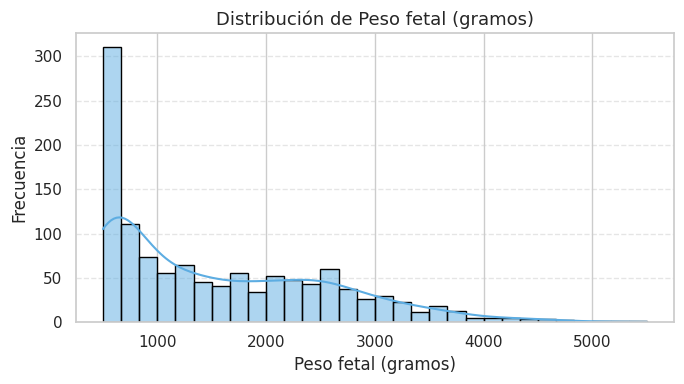

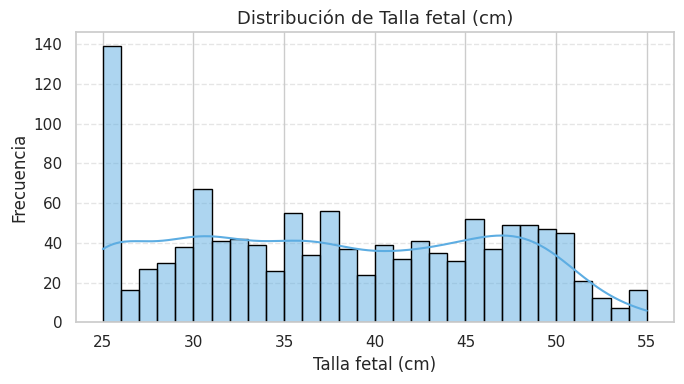

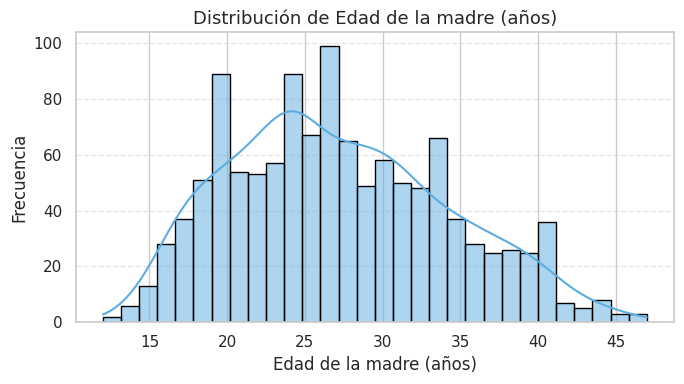

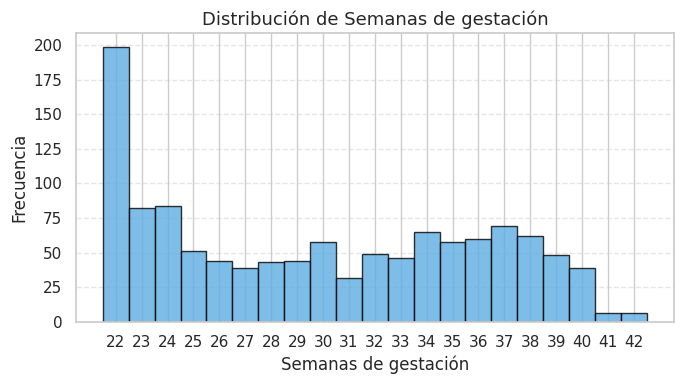

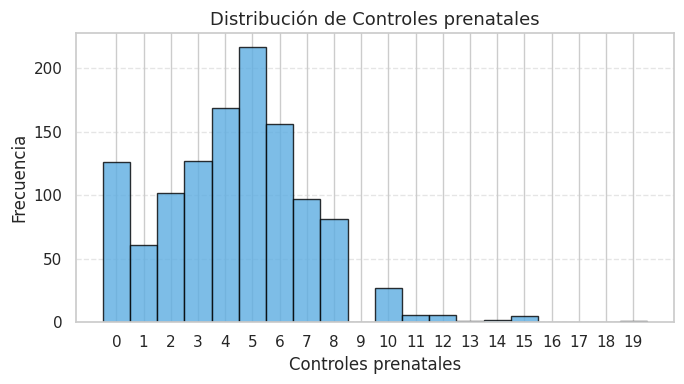

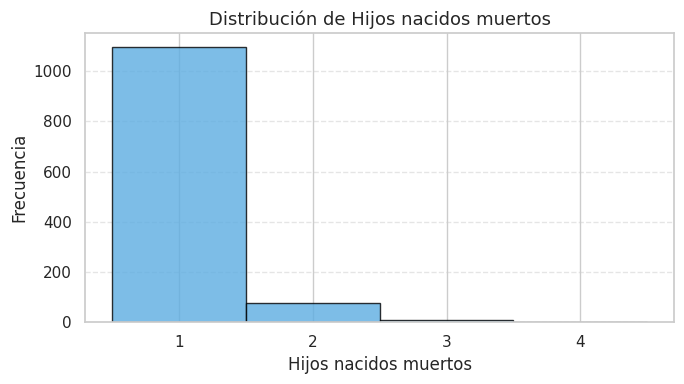

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Variables
variables_continuas = ['peso', 'talla', 'edad_mad']
variables_discretas = ['sem_gest', 'con_pren', 'hij_nacm']

# Diccionario de títulos (mismos que boxplots)
titulos = {
    'peso': 'Peso fetal (gramos)',
    'talla': 'Talla fetal (cm)',
    'sem_gest': 'Semanas de gestación',
    'edad_mad': 'Edad de la madre (años)',
    'con_pren': 'Controles prenatales',
    'hij_nacm': 'Hijos nacidos muertos'
}

# Estilo general
sns.set_style("whitegrid")
color_azul = '#5DADE2'

def plot_distribucion(df, variable, tipo):

    data = df[variable].dropna()
    titulo = titulos.get(variable, variable)

    plt.figure(figsize=(7, 4))

    # VARIABLES CONTINUAS
    if tipo == 'continua':
        sns.histplot(
            data,
            kde=True,
            bins=30,
            color=color_azul,
            edgecolor='black'
        )

    # VARIABLES DISCRETAS
    elif tipo == 'discreta':
        data = data.astype(int)
        min_val = data.min()
        max_val = data.max()
        bins = np.arange(min_val - 0.5, max_val + 1.5, 1)

        plt.hist(
            data,
            bins=bins,
            color=color_azul,
            edgecolor='black',
            alpha=0.8
        )
        plt.xticks(range(min_val, max_val + 1))

    plt.title(f'Distribución de {titulo}', fontsize=13)
    plt.xlabel(titulo)
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Ejecutar gráficos
for var in variables_continuas:
    plot_distribucion(df, var, 'continua')

for var in variables_discretas:
    plot_distribucion(df, var, 'discreta')


**Boxplots – detección de outliers**

Si bien el análisis de distribuciones permite identificar la forma general, asimetrías y concentraciones de las variables, este enfoque resulta limitado para evaluar de manera precisa la magnitud y localización de valores extremos.

En contextos como el de la mortalidad fetal, la presencia de observaciones atípicas no necesariamente implica errores de medición, sino que puede representar eventos clínicamente críticos o perfiles de riesgo extremo que requieren una interpretación diferenciada.

Con el objetivo de profundizar en la detección sistemática de outliers y evaluar su impacto potencial sobre los análisis multivariados, se complementa el análisis univariado mediante boxplots. Esta visualización permite identificar rangos intercuartílicos, dispersión central y valores extremos de forma comparativa entre variables, facilitando la toma de decisiones sobre estrategias de tratamiento de outliers, tales como su conservación, segmentación o el uso de métodos robustos en etapas posteriores de modelado.

Este análisis es particularmente relevante para variables biológicas y reproductivas, donde los valores extremos pueden estar asociados a condiciones estructurales de vulnerabilidad, fallas en el acceso oportuno a servicios de salud o antecedentes obstétricos de alto riesgo, elementos centrales para la identificación de perfiles de vulnerabilidad materna

Este análisis busca identificar valores extremos que puedan representar riesgo biológico, errores de registro o eventos poco frecuentes relevantes para el análisis de mortalidad fetal.

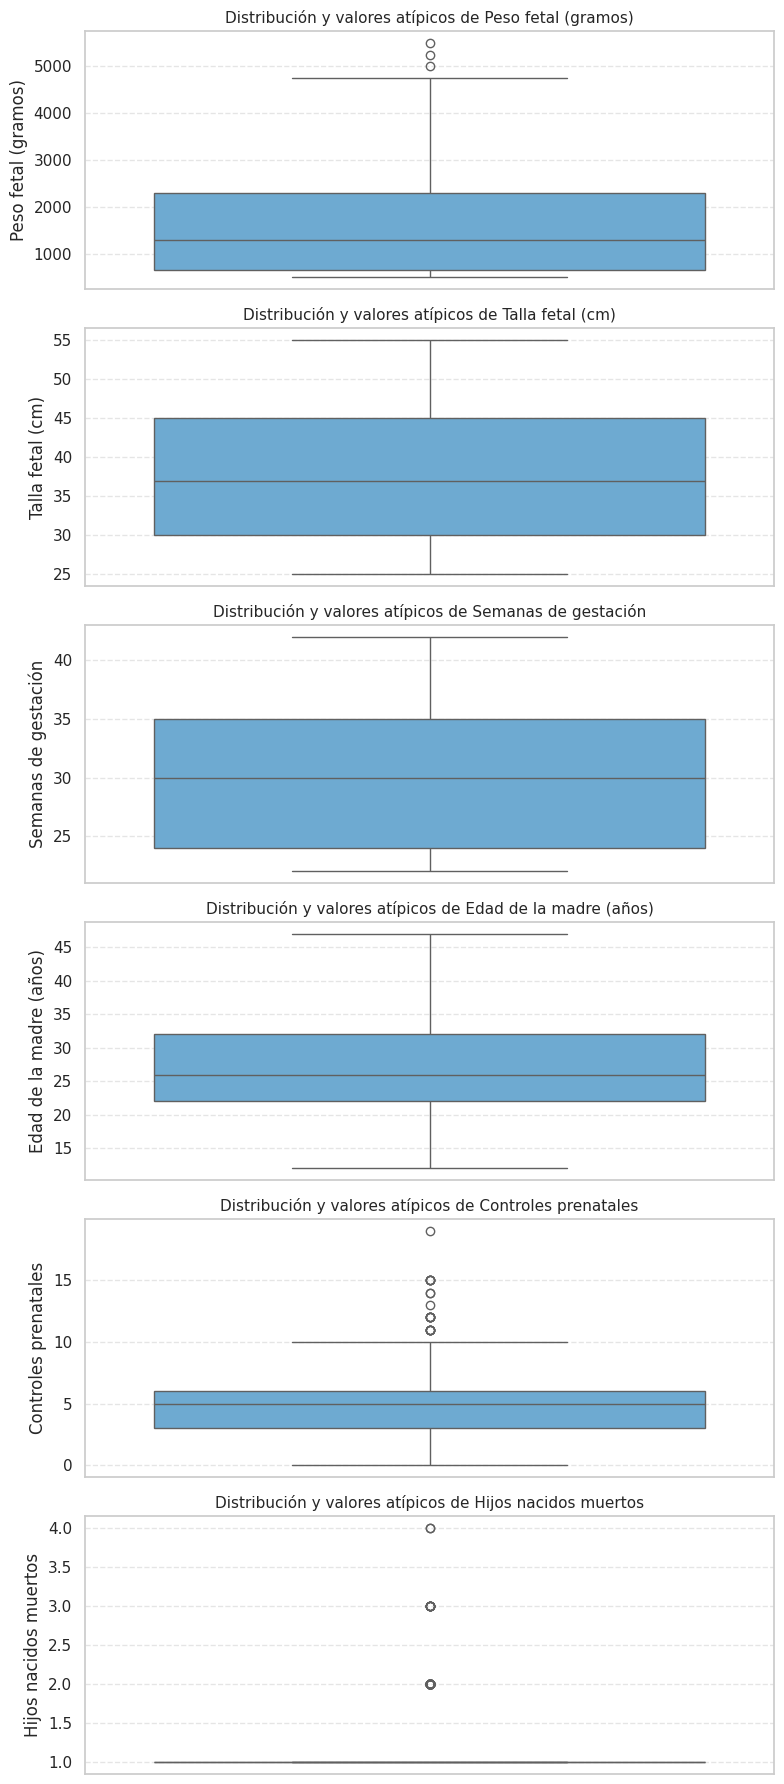

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general
sns.set_style("whitegrid")
color_azul = '#5DADE2'

# Lista de variables y etiquetas
variables = [
    ('peso', 'Peso fetal (gramos)'),
    ('talla', 'Talla fetal (cm)'),
    ('sem_gest', 'Semanas de gestación'),
    ('edad_mad', 'Edad de la madre (años)'),
    ('con_pren', 'Controles prenatales'),
    ('hij_nacm', 'Hijos nacidos muertos')
]

# Crear figura con subplots verticales
fig, axes = plt.subplots(len(variables), 1, figsize=(8, 18))

for ax, (var, label) in zip(axes, variables):
    sns.boxplot(
        y=df[var],
        color=color_azul,
        ax=ax
    )
    ax.set_title(f'Distribución y valores atípicos de {label}', fontsize=11)
    ax.set_ylabel(label)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


**Análisis de Correlación de "Esfuerzo de Atención" y Viabilidad Biológica**

Se evalúa la relación entre las variables cuantitativas que determinan la viabilidad del feto frente a la intervención del sistema de salud. Para este propósito, se utiliza el Coeficiente de Correlación de Rangos de Spearman ($\rho$).

Justificación técnica: Se opta por Spearman en lugar de Pearson debido a que variables como el "Número de controles prenatales" (con_pren) y la "Edad gestacional" (sem_gest) presentan distribuciones no normales, datos discretos (con saltos) y posibles relaciones no lineales.

Spearman permite capturar relaciones monótonas de manera robusta ante valores atípicos.

Objetivos del análisis:

* Identificar el riesgo por edad materna: Evaluar si existe una correlación negativa entre edad_mad y sem_gest, lo cual indicaría que los extremos de la vida reproductiva se asocian a partos prematuros.
* Evaluar la eficacia del control prenatal: Analizar la correlación positiva entre con_pren y el peso/talla del feto. Una correlación débil en este punto sugeriría que el incremento en la cantidad de controles no se traduce necesariamente en un mejor desarrollo fetal, apuntando a deficiencias en la calidad de la atención.
* Detección de Riesgo Acumulado: Observar la relación entre el historial de pérdidas previas (hij_nacm) y la viabilidad del embarazo actual.

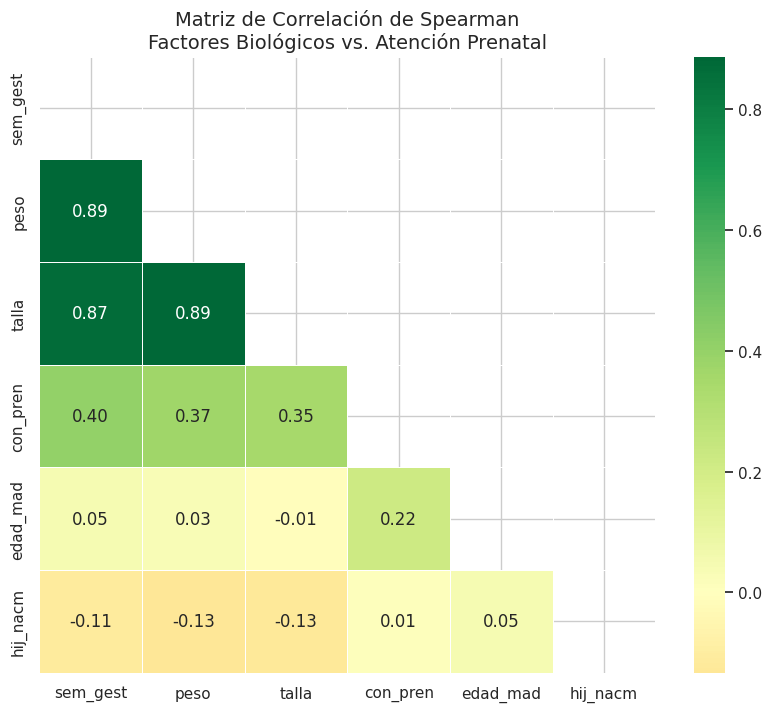

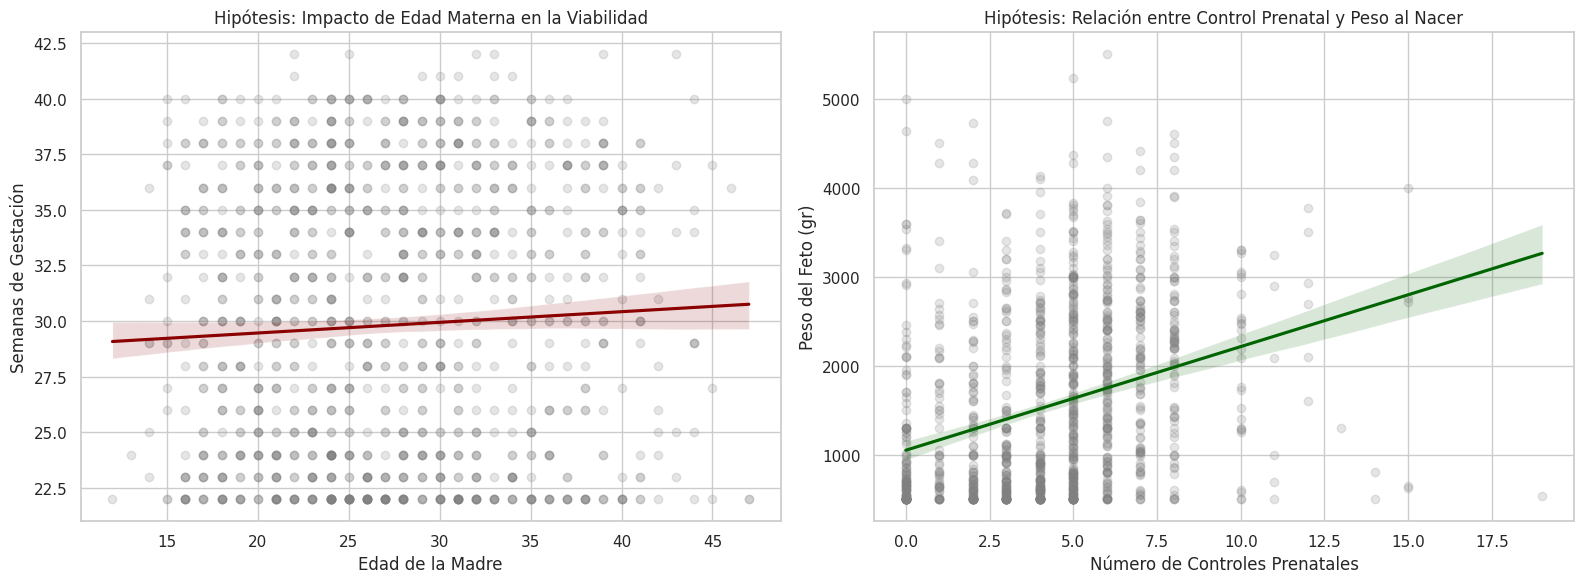

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar el dataset
file_path = 'dataset__limpio.csv'
df = pd.read_csv(file_path)

# 2. Selección de variables de interés para el análisis de "Esfuerzo de Atención"
vars_interes = ['sem_gest', 'peso', 'talla', 'con_pren', 'edad_mad', 'hij_nacm']

# Filtrar solo estas variables y manejar valores nulos para el análisis estadístico
df_subset = df[vars_interes].dropna()

# 3. Cálculo de la Matriz de Spearman
corr_spearman = df_subset.corr(method='spearman')

# 4. Visualización de la Matriz (Heatmap)
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool)) # Máscara estética

sns.heatmap(corr_spearman,
            mask=mask,
            annot=True,
            cmap='RdYlGn', # Verde (Positivo), Rojo (Negativo)
            fmt=".2f",
            center=0,
            square=True,
            linewidths=.5)

plt.title('Matriz de Correlación de Spearman\nFactores Biológicos vs. Atención Prenatal', fontsize=14)
plt.show()

# 5. Gráficos de dispersión para validación de hipótesis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hipótesis 1: Edad Materna vs Semanas de Gestación
sns.regplot(ax=axes[0], x='edad_mad', y='sem_gest', data=df_subset,
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'darkred'})
axes[0].set_title('Hipótesis: Impacto de Edad Materna en la Viabilidad')
axes[0].set_xlabel('Edad de la Madre')
axes[0].set_ylabel('Semanas de Gestación')

# Hipótesis 2: Controles Prenatales vs Peso Fetal
sns.regplot(ax=axes[1], x='con_pren', y='peso', data=df_subset,
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'darkgreen'})
axes[1].set_title('Hipótesis: Relación entre Control Prenatal y Peso al Nacer')
axes[1].set_xlabel('Número de Controles Prenatales')
axes[1].set_ylabel('Peso del Feto (gr)')

plt.tight_layout()
plt.show()

In [ ]:
# Coeficiente de Spearman
valor_correlacion = df[['con_pren', 'sem_gest']].corr(method='spearman').iloc[0,1]
print(f"Coeficiente de Spearman: {valor_correlacion}")

Coeficiente de Spearman: 0.4017388573421682


**El Triángulo Biológico (Peso, Talla, Semanas de gestación)**: Correlación de 0.87 a 0.89

Existe una relación lineal casi perfecta. Esto confirma la consistencia de los datos: a más tiempo de gestación, mayor crecimiento.

Estas tres variables se comportan como una sola "dimensión de madurez". Si un clúster tiene valores altos aquí pero el desenlace es muerte, estamos ante el escenario de mayor prevenibilidad, pues el feto ya era biológicamente viable.

**Control Prenatal (con_pren):** Correlación de  0.35 a 0.40

La correlación con el peso y semanas de gestación es positiva pero moderada, lo que indica que el control prenatal ayuda, pero no garantiza el éxito.

Los resultados sugieren que hay un grupo de madres que, a pesar de tener controles, no logran que el feto llegue a término o gane peso, aquí es donde entra la oportunidad de mejora de Calidad de Atención.

**Edad Materna (edad_mad)**: Correlación de 0.05 a 0.01

Estos resultados indican que la edad de la madre no parece determinar la duración del embarazo o el peso del feto de forma directa en este dataset, esto desafía la literatura tradicional que culpa a la edad (adolescente o avanzada) como causa única, lo que indica que la causa de la muerte fetal no es la edad de la madre, sino factores externos.

**El Historial de Riesgo Silencioso**: Correlación de -0.11 a -0.13

Existe una tendencia leve, a más hijos nacidos muertos anteriormente, menor es el peso y las semanas del embarazo actual, aun que la corrrelación es débil, el signo negativo es consistente, lo que indica un riesgo acumulado, esta variable será un "activador" de alerta para perfiles de vulnerabilidad recurrente.


**Correlación Edad Materna y Controles** Correlación 0.22

Las madres de mayor edad tienden a tener ligeramente más controles que las jóvenes, esto sugiere que las madres jóvenes o adolescentes podrían estar más expuestas por falta de adherencia al control prenatal.


**El análisis de Spearman** revela que, si bien la viabilidad biológica sigue patrones esperados (Peso/Semanas), la intervención del sistema de salud (Controles Prenatales) muestra una eficacia moderada ($\rho \approx 0.40$). La casi nula correlación de la edad materna con los indicadores de desarrollo fetal sugiere que la mortalidad en este grupo de estudio responde a determinantes distintos a la biología reproductiva básica, reforzando la hipótesis de que factores socio-territoriales y de gestión hospitalaria son los principales moduladores del desenlace fatal.


El gráfico de **Edad de la Madre vs. Semanas de Gestación** muestra una línea de regresión plana y una correlación casi nula ($\rho = 0.05$).
Al no ser la biología de la edad el factor determinante, se puede demostrar que la vulnerabilidad (instrucción, etnia, acceso geográfico) es la que realmente empuja estos casos hacia el desenlace fatal.

El gráfico de **Controles Prenatales vs. Peso Fetal **muestra una pendiente positiva ($\rho = 0.37$), pero con una dispersión muy alta.
Si bien más controles ayudan, la relación es moderada, se observa que hay fetos con muchos controles (10 o más) que siguen naciendo con pesos extremadamente bajos o en semanas tempranas. Esto sugiere que cumplir con el número de citas no garantiza el éxito si la calidad de la atención o la capacidad de resolución del centro de salud es baja.

**Identificación de la Prevenibilidad: **Aquellos puntos con muchos controles y bajo peso o pocas semanas son los llamados falsos protegidos, es decir, madres que hicieron lo correcto siguiendo el sistema, pero el sistema falló en proteger la viabilidad del feto, estos son los casos de mortalidad potencialmente prevenible por gestión.

**Conclusión:** Los resultados confirman que la viabilidad fetal en el contexto ecuatoriano no está condicionada por la edad materna ($\rho = 0.05$), lo que desplaza el foco del análisis hacia determinantes extrínsecos. Por otro lado, la relación moderada entre el control prenatal y el peso ($\rho = 0.37$) evidencia una brecha en la eficacia del sistema: la asistencia a controles es una condición necesaria pero no suficiente para garantizar la viabilidad, sugiriendo fallas estructurales en la detección oportuna de riesgos.

**Análisis de la Sincronía del Desarrollo Fetal: El Triángulo Biológico**

La relación entre el peso, la talla y las semanas de gestación constituye lo que se denomina el 'Triángulo Biológico'. Este análisis es fundamental para validar la integridad de los datos y, sobre todo, para establecer la línea base de viabilidad del feto al momento del fallecimiento.

A diferencia de los determinantes sociales, que presentan una alta variabilidad, las variables biológicas en condiciones normales deben mostrar una progresión lineal y altamente correlacionada.

El objetivo de este análisis es:

1. Validar la consistencia clínica: Confirmar que los registros de óbitos fetales siguen las leyes del desarrollo intrauterino (a mayor edad gestacional, mayor peso y talla).

2. Identificar el umbral de viabilidad: Visualizar la densidad de casos que alcanzan semanas de gestación y pesos considerados como 'viables' según los estándares de la OMS (generalmente >22 semanas o >500 gramos), lo cual permite dimensionar la magnitud de la muerte fetal que ocurre en etapas donde la medicina moderna tiene mayores oportunidades de intervención.

A continuación, se presenta una matriz de dispersión segmentada por Área de Residencia, con el fin de observar si el entorno geográfico de la madre altera estas trayectorias de crecimiento biológico o si la vulnerabilidad territorial se manifiesta de forma externa a la biología fetal."

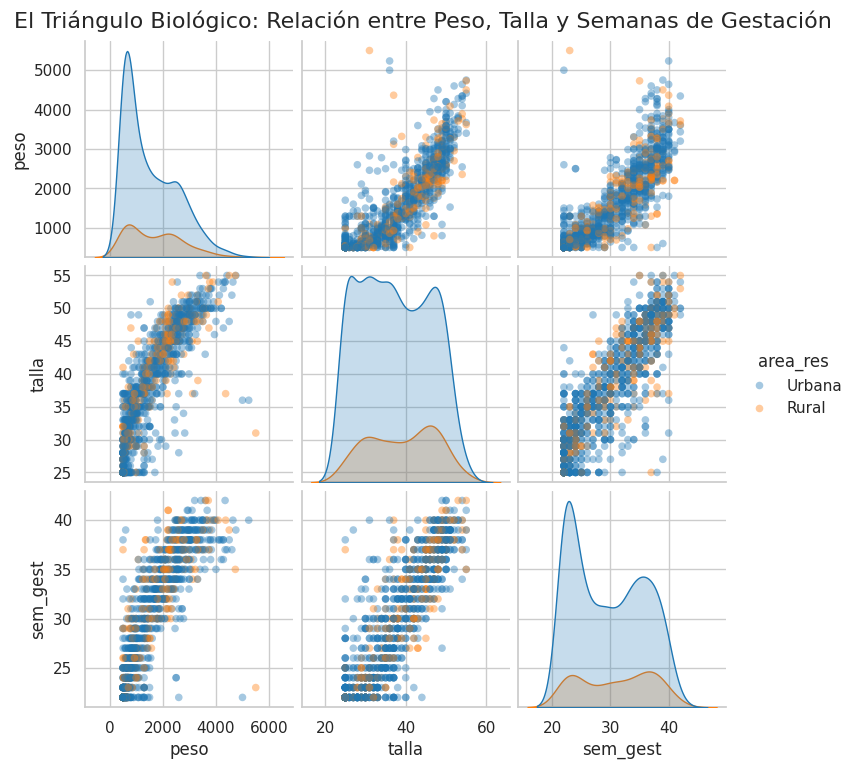

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar datos
df = pd.read_csv('dataset__limpio.csv')

# 2. Selección de las variables del Triángulo Biológico y el Área para contrastar
biotriangulo = ['peso', 'talla', 'sem_gest', 'area_res']
df_bio = df[biotriangulo].dropna()

# 3. Crear el Pairplot (Matriz de dispersión)
# Esto generará histogramas en la diagonal y dispersión en los cruces
g = sns.pairplot(
    df_bio,
    hue='area_res',
    palette={'Urbana': '#1f77b4', 'Rural': '#ff7f0e'},
    diag_kind='kde', # Densidad en la diagonal
    plot_kws={'alpha': 0.4, 's': 30, 'edgecolor': 'none'}
)

# 4. Ajustes estéticos
g.fig.suptitle('El Triángulo Biológico: Relación entre Peso, Talla y Semanas de Gestación', y=1.02, fontsize=16)
plt.show()

**Interpretación de Resultados:**

1. Sincronía Biológica Universal

El análisis mediante pairplot demuestra que el crecimiento intrauterino (peso y talla) mantiene una sincronía robusta con la edad gestacional ($\rho > 0.85$), independientemente del área de residencia. Este hallazgo es fundamental: confirma que el fenómeno de la muerte fetal en Ecuador no discrimina la capacidad biológica de desarrollo. Tanto en entornos urbanos como rurales, los fetos siguen la misma trayectoria de madurez, lo que permite utilizar estas variables como un estándar de viabilidad para el modelo de clasificación.

2. El Hallazgo de la "Biología Equitativa" vs. "Acceso Desigual"

Uno de los puntos más reveladores es que las distribuciones de densidad (KDE) no muestran un desplazamiento significativo hacia la izquierda en las zonas rurales. Esto sugiere que la mortalidad fetal rural no se debe necesariamente a fetos más débiles o pequeños, sino que, ante fetos de similar desarrollo biológico, el sistema de salud o el entorno territorial no ofrece la misma capacidad de respuesta que en la zona urbana.

3. Definición del Perfil de Prevenibilidad

La fuerte correlación observada permite establecer una "zona de viabilidad" en el gráfico (generalmente situada en el cuadrante superior derecho: $>28$ semanas, $>1000$g y $>35$cm). Los puntos acumulados en esta zona representan el núcleo de la "Mortalidad Fetal Potencialmente Prevenible".
Si la sincronía biológica era la adecuada para la supervivencia fuera del útero, la causa de la defunción debe buscarse en el Patient Journey (falta de controles o atención deficiente en el parto) o en las Barreras Geográficas (demoras en el traslado).

4. Hacia el Modelado de Vulnerabilidad

Dado que el entorno geográfico no altera la biología fundamental, se confirma la hipótesis de que las vulnerabilidades territoriales son extrínsecas. Para el clustering, esto significa que el algoritmo no agrupará a las madres rurales por una "biología diferente", sino por la desconexión entre su necesidad biológica (un feto viable) y la respuesta sanitaria recibida.

**Análisis de Independencia: Brecha Territorial en el Acceso a Salud**

Para validar la hipótesis de la fragmentación territorial, se aplicó una prueba de Chi-cuadrado de Pearson evaluando la relación entre el Área de Residencia (Urbana/Rural) y la Suficiencia de Controles Prenatales (categorizada como Insuficiente 0-4 y Suficiente 5+ según estándares de la OMS).

Para evitar el sesgo por edad gestacional, se definió la variable 'Suficiencia Dinámica de Controles' siguiendo estas reglas:

* Si murió en el 1er Trimestre (≤ 12 sem): Debe tener al menos 1 control.
* Si murió en el 2do Trimestre (13 - 27 sem): Debe tener al menos 3 controles (el del 1ero + 2 del 2do).
* Si murió en el 3er Trimestre (≥ 28 sem): Debe tener al menos 5 a 7 controles (dependiendo de la semana exacta).

Esto permite diferenciar entre la falta de acceso al sistema y la interrupción biológica temprana del embarazo

Este análisis busca determinar si el entorno geográfico condiciona de manera significativa la oportunidad de atención. Un resultado estadísticamente significativo confirmaría que la residencia rural actúa como un factor de exclusión sistémico, donde la lejanía o la falta de infraestructura se traduce en una trayectoria de control deficiente. Este hallazgo es el precursor para el modelo de clustering, permitiendo segmentar perfiles de vulnerabilidad basados en el aislamiento geográfico.

<Figure size 1000x600 with 0 Axes>

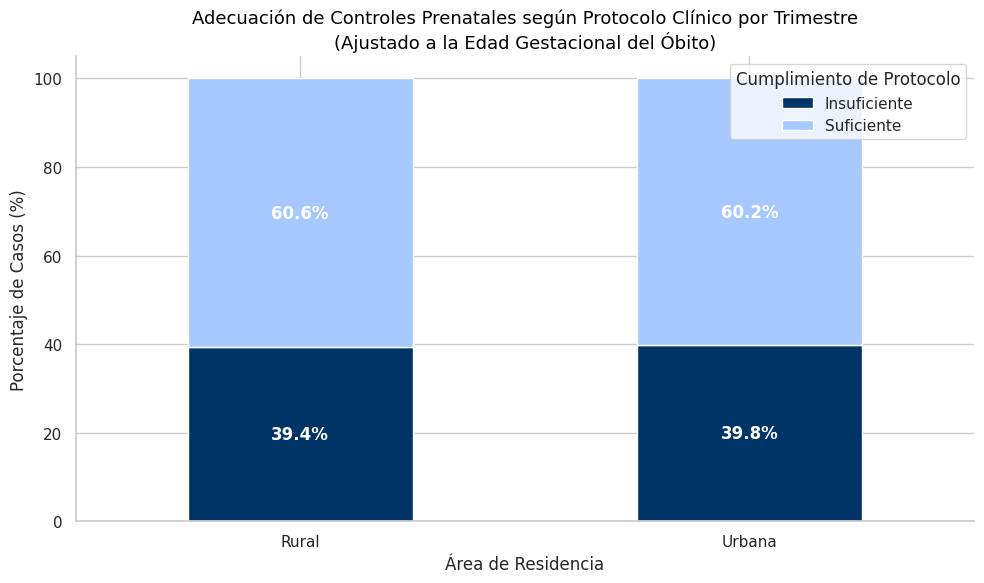

--- Resultados con Lógica Clínica ---
Valor p (Chi-cuadrado): 0.9723


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. Cargar datos
df = pd.read_csv('dataset__limpio.csv')

# 2. Lógica por trimestre
def clasificar_clinico(row):
    semanas = row['sem_gest']
    controles = row['con_pren']

    # Meta según protocolo:
    if semanas <= 12:
        meta = 1
    elif semanas <= 27:
        meta = 3  # 1 del primer trim + 2 del segundo
    elif semanas <= 33:
        meta = 4  # + el de la semana 30
    elif semanas <= 35:
        meta = 5  # + el de la semana 34
    elif semanas <= 37:
        meta = 6  # + el de la semana 36
    else:
        meta = 7  # + el de la semana 38/40

    if controles >= meta:
        return 'Suficiente (Protocolo)'
    else:
        return 'Insuficiente (Protocolo)'

df['control_clinico'] = df.apply(clasificar_clinico, axis=1)

# 3. Prueba de Chi-cuadrado
tabla_clinica = pd.crosstab(df['area_res'], df['control_clinico'])
chi2, p, dof, ex = chi2_contingency(tabla_clinica)

# 4. Gráfico en Tonos Azules
plt.figure(figsize=(10, 6))
tabla_pct = tabla_clinica.div(tabla_clinica.sum(1), axis=0) * 100

azul_fuerte = "#003366"
azul_claro = "#A6C8FF"

ax = tabla_pct.plot(kind='bar', stacked=True, color=[azul_fuerte, azul_claro], figsize=(10, 6), rot=0)

# Título
plt.title('Adecuación de Controles Prenatales según Protocolo Clínico por Trimestre\n(Ajustado a la Edad Gestacional del Óbito)',
          fontsize=13,
          fontweight='normal',
          color='black')

plt.ylabel('Porcentaje de Casos (%)', fontsize=12)
plt.xlabel('Área de Residencia', fontsize=12)
plt.legend(title='Cumplimiento de Protocolo', labels=['Insuficiente', 'Suficiente'], loc='upper right')

for p_bar in ax.patches:
    width, height = p_bar.get_width(), p_bar.get_height()
    x, y = p_bar.get_xy()
    if height > 0:
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center',
                color='white' if height > 40 else 'white', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

print(f"--- Resultados con Lógica Clínica ---")
print(f"Valor p (Chi-cuadrado): {p:.4f}")

Este gráfico muestra el porcentaje de casos de mortalidad fetal con controles prenatales Insuficientes o Suficientes según un protocolo clínico ajustado por el trimestre de gestación, diferenciado por el área de residencia (Rural vs. Urbana).

**Suficiencia de Controles**

Tanto en las áreas rurales como urbanas, la mayoría de los casos de mortalidad fetal (aproximadamente el 60%) cumplieron con el protocolo clínico de controles prenatales ajustado por trimestre.

El resultado más importante es que, al ajustar la suficiencia de controles prenatales según la edad gestacional del óbito, no hay una diferencia estadísticamente significativa en el cumplimiento del protocolo entre las áreas rurales y urbanas (p-value = 0.9723, que es mucho mayor que el umbral común de 0.05). Esto significa que, contrario a la expectativa inicial, la residencia rural no se traduce automáticamente en una mayor insuficiencia de controles prenatales cuando se considera la etapa del embarazo en la que ocurrió el fallecimiento fetal.

Este hallazgo es crucial porque sugiere que la causa de la mortalidad fetal potencialmente prevenible en Ecuador no se debe a una simple falta de acceso o adherencia a los controles prenatales en las zonas rurales. En cambio, si las madres asisten a los controles de manera similar en ambos entornos, la atención debe centrarse en otros factores, como la calidad de la atención recibida durante esos controles, la capacidad resolutiva de los centros de salud rurales, o la logística para atender emergencias y traslados oportunos.



**Análisis de Interseccionalidad: Educación, Territorio y Acceso Clínico**

Para determinar si el impacto de la instrucción materna sobre la salud prenatal varía según el entorno geográfico, se realizó un análisis cruzado segmentado por área de residencia. Al ajustar la suficiencia de controles según el protocolo clínico por trimestre, este análisis busca identificar si la educación actúa como un factor protector universal o si su efecto se ve mitigado por las barreras físicas del entorno rural.

Este enfoque de interseccionalidad es vital para el modelo de clustering, ya que permite diferenciar entre una vulnerabilidad puramente educativa y una vulnerabilidad territorial-cognitiva, donde el sistema de salud podría estar fallando en comunicar la importancia de los controles a sectores específicos de la población.

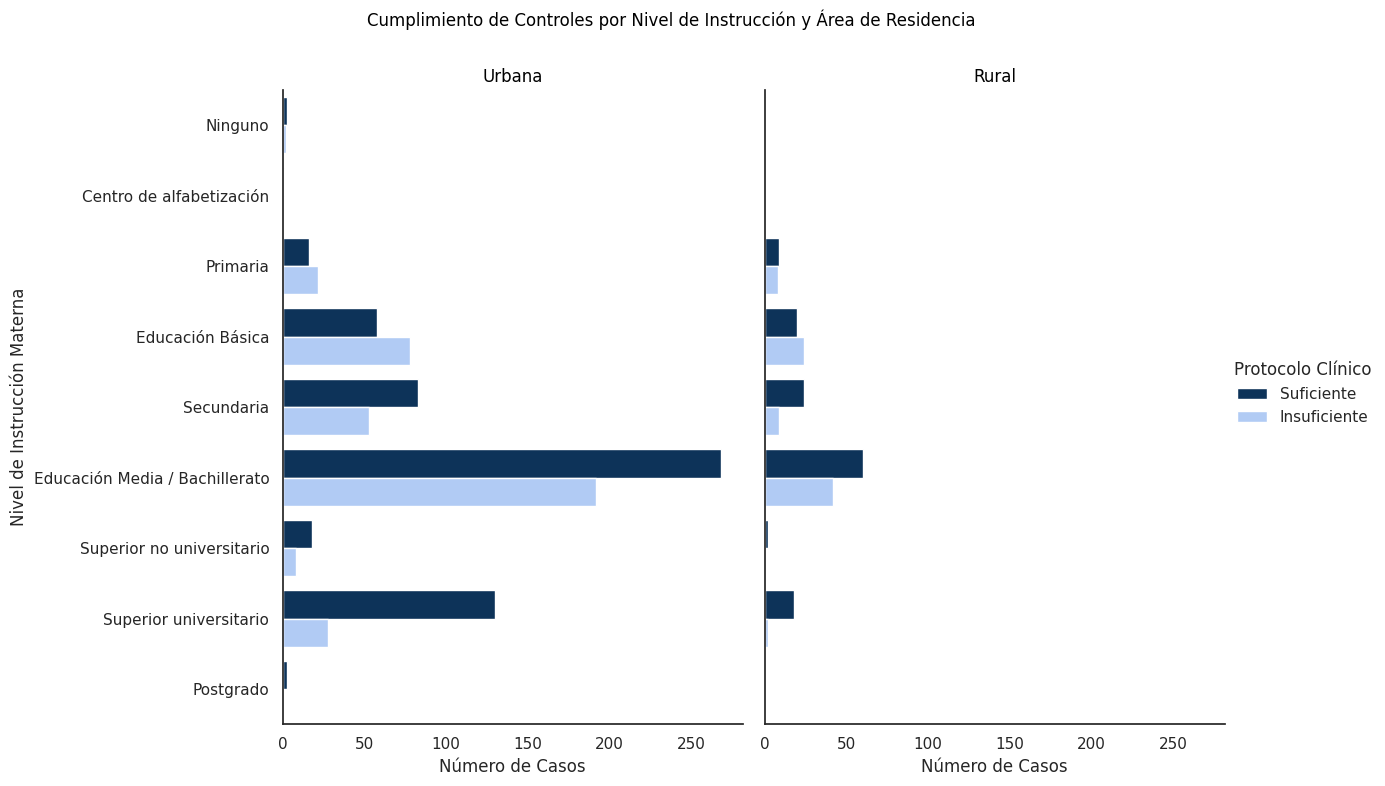

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar datos
df = pd.read_csv('dataset__limpio.csv')

# 2. Lógica por trimestre
def clasificar_clinico(row):
    semanas = row['sem_gest']
    controles = row['con_pren']
    if semanas <= 12: meta = 1
    elif semanas <= 27: meta = 3
    elif semanas <= 33: meta = 4
    elif semanas <= 35: meta = 5
    elif semanas <= 37: meta = 6
    else: meta = 7
    return 'Suficiente' if controles >= meta else 'Insuficiente'

df['control_clinico'] = df.apply(clasificar_clinico, axis=1)

# 3. Órden jerárquico por instrucción
orden_instruccion = [
    'Ninguno',
    'Centro de alfabetización',
    'Primaria',
    'Educación Básica',
    'Secundaria',
    'Educación Media / Bachillerato',
    'Superior no universitario',
    'Superior universitario',
    'Postgrado'
]

# 4. Gráfico
sns.set_style("white")
g = sns.catplot(
    data=df,
    y='niv_inst',
    hue='control_clinico',
    col='area_res',
    kind='count',
    order=orden_instruccion,
    palette=['#003366', '#A6C8FF'], # Azul medianoche (Insuficiente), Azul claro (Suficiente)
    height=8,
    aspect=0.8
)

# 5. Títulos
g.set_titles("{col_name}", size=14, color='black', fontweight='normal')
g.set_axis_labels("Número de Casos", "Nivel de Instrucción Materna", fontsize=12)
g._legend.set_title("Protocolo Clínico")

# Ajustar títulos de cada gráfico
for ax in g.axes.flat:
    ax.set_title(ax.get_title(), fontweight='normal', color='black')

plt.subplots_adjust(top=0.88)
g.fig.suptitle('Cumplimiento de Controles por Nivel de Instrucción y Área de Residencia',
               fontsize=12, color='black', fontweight='normal')

plt.show()

La educación materna parece ser un factor protector en ambos entornos, ya que niveles más altos de instrucción se correlacionan con un mayor cumplimiento del protocolo de controles prenatales.

Brecha en Calidad/Acceso: A pesar de que el análisis Chi-cuadrado previo no mostró una diferencia significativa general en la suficiencia de controles entre áreas rurales y urbanas, este gráfico detallado revela que la combinación de baja instrucción y residencia rural puede agravar la vulnerabilidad. Aunque las madres rurales asisten a controles en una proporción similar a las urbanas en términos generales, la calidad de la atención o la capacidad de respuesta del sistema de salud ante la educación específica de las madres en las zonas rurales podría ser deficiente.

Este análisis es crucial para el modelado de clustering, ya que permite identificar subgrupos específicos de vulnerabilidad (por ejemplo, madres rurales con educación básica) que podrían requerir intervenciones dirigidas no solo a aumentar la cantidad de controles, sino también a mejorar la comunicación, la calidad de la atención y la accesibilidad de los servicios de salud adaptados a sus perfiles socio-educativos y geográficos.


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 1. Cargar datos
df = pd.read_csv('dataset__limpio.csv')

# 2. Protocolo clínico
def clasificar_clinico(row):
    semanas = row['sem_gest']
    controles = row['con_pren']
    if semanas <= 12: meta = 1
    elif semanas <= 27: meta = 3
    elif semanas <= 33: meta = 4
    elif semanas <= 35: meta = 5
    elif semanas <= 37: meta = 6
    else: meta = 7
    return 'Suficiente' if controles >= meta else 'Insuficiente'

df['control_clinico'] = df.apply(clasificar_clinico, axis=1)

# 3. Crear Tabla de Contingencia
tabla = pd.crosstab(df['niv_inst'], df['control_clinico'])

# 4. Cálculo de Chi-Cuadrado y V de Cramer
chi2, p, dof, ex = chi2_contingency(tabla)

# Función para calcular V de Cramer (mide fuerza de asociación de 0 a 1)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

v_cramer = cramers_v(df['niv_inst'], df['control_clinico'])

print(f"--- Análisis de Correlación (Asociación) ---")
print(f"Valor p (Significancia): {p:.4e}")
print(f"V de Cramer (Fuerza de asociación): {v_cramer:.4f}")

# 5. Interpretación automática
if p < 0.05:
    print("\nConclusión: Existe una correlación estadísticamente significativa.")
    if v_cramer < 0.1: interpretacion = "muy débil"
    elif v_cramer < 0.3: interpretacion = "moderada"
    else: interpretacion = "fuerte"
    print(f"La fuerza de la relación es {interpretacion}.")
else:
    print("\nConclusión: No existe una correlación significativa entre las variables.")

--- Análisis de Correlación (Asociación) ---
Valor p (Significancia): 3.7607e-12
V de Cramer (Fuerza de asociación): 0.2300

Conclusión: Existe una correlación estadísticamente significativa.
La fuerza de la relación es moderada.


Al realizar un análisis de correlación, se evidencia que el nivel de instrucción materna sí influye en la adherencia al protocolo de controles prenatales, aunque la relación no es extremadamente fuerte. Esto apoya la idea de que la educación es un factor relevante en el acceso y aprovechamiento de la atención de salud durante el embarazo.

**Análisis de Disparidad Étnica en el Seguimiento Prenatal**

El sistema de salud debe garantizar la equidad no solo geográfica, sino también intercultural. Mediante este análisis, se evalúa si la autoidentificación étnica de la madre influye en el cumplimiento del protocolo clínico de controles prenatales.

Identificar si ciertos grupos étnicos presentan sistemáticamente niveles de insuficiencia más altos es crucial para determinar si las estrategias de prevención de mortalidad fetal fallan por falta de pertinencia cultural, o si el sistema de salud no logra integrar de manera efectiva a poblaciones históricamente vulnerabilizadas. Este hallazgo permitirá al modelo de clustering identificar si la etnia actúa como un factor de riesgo aislado o si se potencia al interactuar con el nivel de instrucción y el territorio.

<Figure size 1200x700 with 0 Axes>

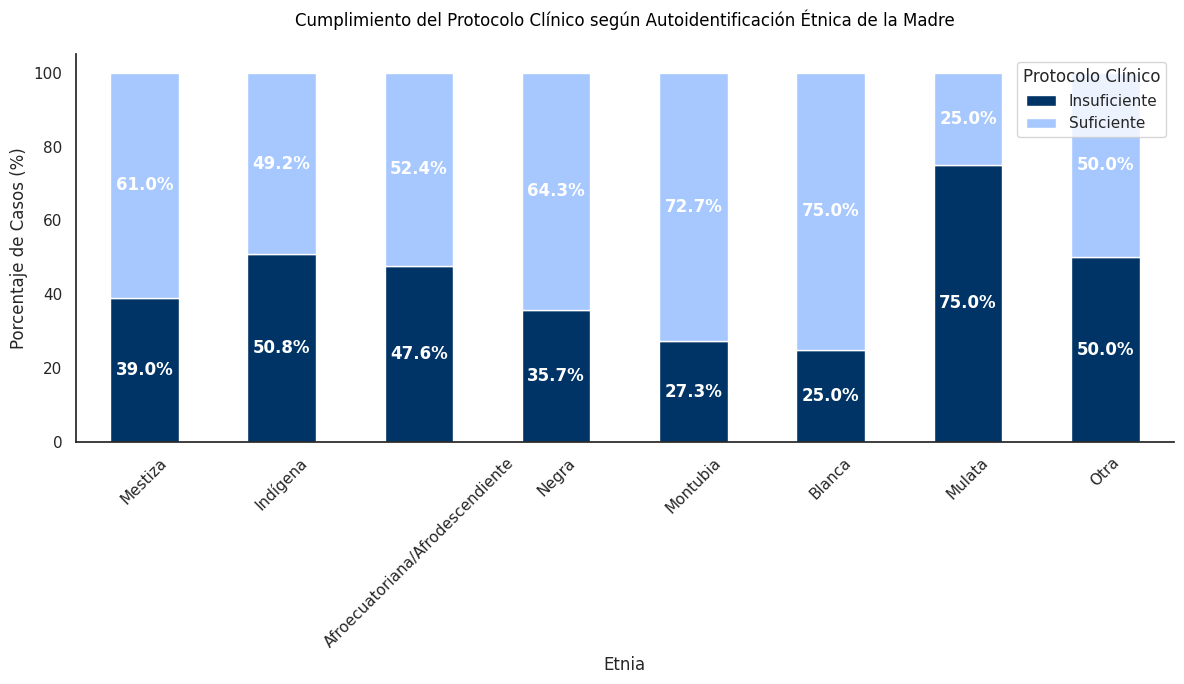

--- Resultados Estadísticos ---
Valor p (Chi-cuadrado): 3.9209e-01


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. Cargar datos
df = pd.read_csv('dataset__limpio.csv')

# 2. Asegurar la variable de control clínico (Protocolo por trimestre)
def clasificar_clinico(row):
    semanas = row['sem_gest']
    controles = row['con_pren']
    if semanas <= 12: meta = 1
    elif semanas <= 27: meta = 3
    elif semanas <= 33: meta = 4
    elif semanas <= 35: meta = 5
    elif semanas <= 37: meta = 6
    else: meta = 7
    return 'Suficiente' if controles >= meta else 'Insuficiente'

df['control_clinico'] = df.apply(clasificar_clinico, axis=1)

# 3. Crear Tabla de Contingencia: Etnia vs Control Clínico
tabla_etnia = pd.crosstab(df['etnia'], df['control_clinico'])
orden_etnia = tabla_etnia.sum(axis=1).sort_values(ascending=False).index
tabla_etnia = tabla_etnia.reindex(orden_etnia)

# 4. Prueba de Chi-cuadrado
chi2, p, dof, ex = chi2_contingency(tabla_etnia)

# 5. Gráfico de Barras Apiladas
plt.figure(figsize=(12, 7))
tabla_pct = tabla_etnia.div(tabla_etnia.sum(1), axis=0) * 100

# Paleta de Azules Profesionales
azul_fuerte = "#003366"
azul_claro = "#A6C8FF"

ax = tabla_pct.plot(kind='bar', stacked=True, color=[azul_fuerte, azul_claro], figsize=(12, 7), rot=45)

# Título
plt.title('Cumplimiento del Protocolo Clínico según Autoidentificación Étnica de la Madre',
          fontsize=12, fontweight='normal', color='black', pad=20)

plt.ylabel('Porcentaje de Casos (%)', fontsize=12)
plt.xlabel('Etnia', fontsize=12)
plt.legend(title='Protocolo Clínico', labels=['Insuficiente', 'Suficiente'], loc='upper right')

# Añadir etiquetas de porcentaje
for p_bar in ax.patches:
    width, height = p_bar.get_width(), p_bar.get_height()
    x, y = p_bar.get_xy()
    if height > 5: # Solo mostrar si hay espacio
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center',
                color='white' if height > 40 else 'white', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

print(f"--- Resultados Estadísticos ---")
print(f"Valor p (Chi-cuadrado): {p:.4e}")

El análisis de la autoidentificación étnica de la madre frente al cumplimiento del protocolo clínico revela una homogeneidad relativa en la desprotección. Si bien se observan variaciones visuales, donde la población indígena y afrodescendiente presenta niveles de insuficiencia que rondan el 51% y 48% respectivamente, la prueba de Chi-cuadrado ($p = 0.3921$) determina que estas diferencias no son estadísticamente significativas.

Este hallazgo sugiere que la vulnerabilidad sistémica en el control prenatal es un fenómeno que atraviesa las fronteras étnicas en Ecuador. La barrera al acceso parece responder más a la interacción de múltiples factores (educación, calidad del servicio, logística) que a una exclusión basada exclusivamente en la identidad étnica. Para el modelo de clustering, esto implica que la etnia no debe ser analizada de forma aislada, sino como parte de un perfil de riesgo interseccional.

**Análisis de Desplazamiento Intercantonal y Vulnerabilidad por Área**

Para detectar fallas en la red de salud a nivel local, se ha definido la variable 'Desplazamiento Cantonal', que identifica si el deceso ocurrió en un cantón distinto al de residencia. A diferencia del análisis provincial, este enfoque de micro-territorio permite visualizar la dependencia de los cantones periféricos hacia los nodos urbanos de salud.

Se emplea una Correlación de Punto Biserial para determinar si estos traslados afectan a embarazos de mayor edad gestacional, segmentando los resultados por Área de Residencia. Este análisis es el núcleo de la hipótesis de 'Muerte en Tránsito': si las madres de áreas rurales o urbanas marginales deben abandonar su cantón para buscar atención en etapas avanzadas del embarazo, estamos ante una evidencia irrefutable de inequidad en la distribución de la capacidad resolutiva obstétrica del país.

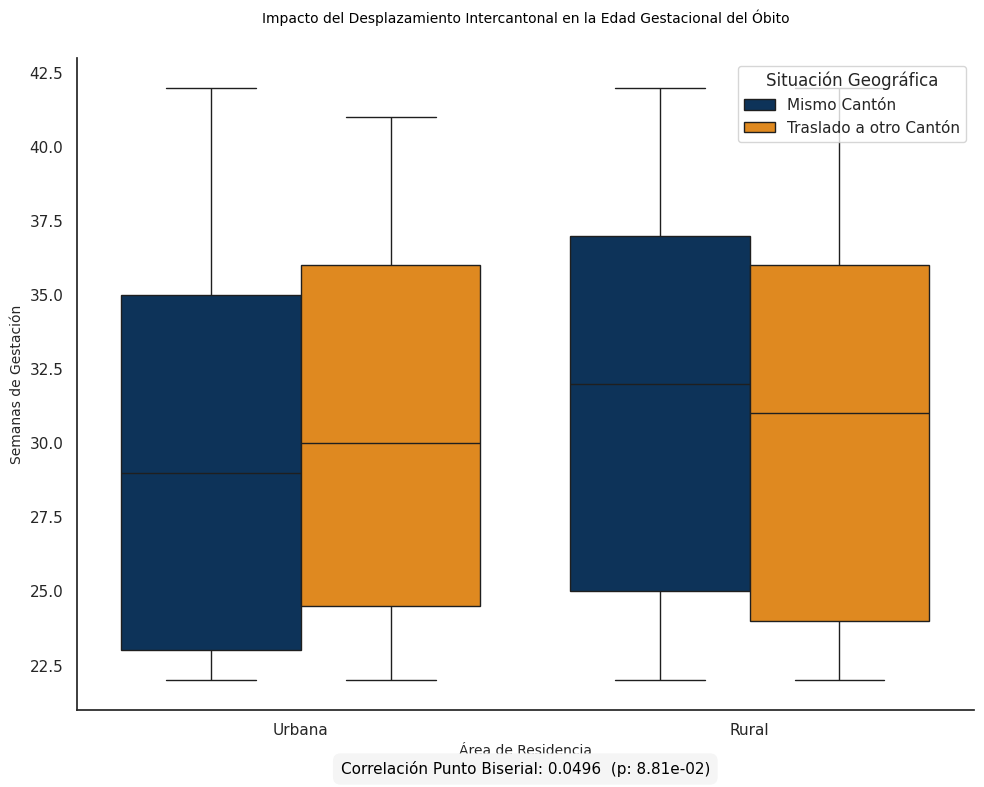

--- Porcentaje de Desplazamiento por Área ---
area_res
Rural     34.38914
Urbana    20.66459
Name: desp_cantonal, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr

# 1. Cargar datos
df = pd.read_csv('dataset__limpio.csv')

# 2. CREACIÓN DE LA VARIABLE DE DESPLAZAMIENTO CANTONAL
# Creamos una versión con texto para que la leyenda sea automática y clara
df['Situacion_Geografica'] = (df['cant_res'] != df['cant_fall']).map({
    True: 'Traslado a otro Cantón',
    False: 'Mismo Cantón'
})
# Mantener la versión numérica para la estadística
df['desp_cantonal'] = (df['cant_res'] != df['cant_fall']).astype(int)

# 3. ANÁLISIS ESTADÍSTICO
corr_gen, p_gen = pointbiserialr(df['desp_cantonal'], df['sem_gest'])

# 4. VISUALIZACIÓN
plt.figure(figsize=(10, 8))

# Paleta colores
colores_dict = {'Mismo Cantón': "#003366", 'Traslado a otro Cantón': "#FF8C00"}

ax = sns.boxplot(
    x='area_res',
    y='sem_gest',
    hue='Situacion_Geografica',
    data=df,
    palette=colores_dict,
    hue_order=['Mismo Cantón', 'Traslado a otro Cantón']
)

# TÍTULO
plt.title('Impacto del Desplazamiento Intercantonal en la Edad Gestacional del Óbito',
          fontsize=10, fontweight='normal', color='black', pad=25)

plt.xlabel('Área de Residencia', fontsize=10)
plt.ylabel('Semanas de Gestación', fontsize=10)

# Ajustar leyenda
plt.legend(title='Situación Geográfica', loc='upper right')

# Añadir el resultado de la correlación
plt.text(0.5, df['sem_gest'].min() - 3,
         f'Correlación Punto Biserial: {corr_gen:.4f}  (p: {p_gen:.2e})',
         ha='center', va='center', fontsize=11, color='black',
         bbox=dict(facecolor='#F5F5F5', edgecolor='none', boxstyle='round,pad=0.5'))

sns.despine()
plt.tight_layout()
plt.show()

# 5. RESUMEN DE DATOS POR ÁREA
print("--- Porcentaje de Desplazamiento por Área ---")
print(df.groupby('area_res')['desp_cantonal'].mean() * 100)

In [ ]:
# 1. Frecuencias absolutas
tabla_desp = pd.crosstab(df['area_res'], df['desp_cantonal'])

# 2. Convertir a porcentajes (frecuencias relativas por fila)
tabla_porcentajes = tabla_desp.div(tabla_desp.sum(axis=1), axis=0) * 100

# 3. Renombrar columnas
tabla_porcentajes.columns = ['Mismo Cantón (%)', 'Traslado a otro Cantón (%)']

print("--- Análisis de Desplazamiento Forzado por Área ---")
print(tabla_porcentajes.round(2)) # 2 decimales

--- Análisis de Desplazamiento Forzado por Área ---
          Mismo Cantón (%)  Traslado a otro Cantón (%)
area_res                                              
Rural                65.61                       34.39
Urbana               79.34                       20.66


Los resultados demuestran que el desplazamiento no afecta de manera equitativa a la población, sino que está fuertemente condicionado por el entorno geográfico. Mientras que en el área urbana el 20.66% de los óbitos fetales ocurrieron tras un traslado fuera del cantón de origen, en el área rural esta cifra asciende al 34.39%.Esta diferencia de casi 14 puntos porcentuales sugiere que las zonas rurales funcionan bajo una lógica de dependencia sanitaria, donde la falta de equipamiento o personal especializado obliga a una de cada tres madres rurales a buscar atención en nodos urbanos de mayor complejidad.Estadísticamente, la Correlación de Punto Biserial ($r = 0.0496; p = 0.0881$) indica que el desplazamiento ocurre de forma transversal a lo largo de diversas etapas del embarazo. Sin embargo, la observación de medianas de edad gestacional más elevadas en los casos de traslado sugiere que el sistema está movilizando a madres con fetos viables (gestaciones avanzadas). Este patrón es característico de una respuesta reactiva ante la emergencia: el traslado no se realiza como una medida preventiva planificada, sino como un recurso de última instancia cuando el compromiso fetal es inminente y la infraestructura local se ve superada.

En conclusión, el desplazamiento intercantonal actúa como un marcador de vulnerabilidad logística, donde el riesgo de óbito fetal se ve agravado por el tiempo y la distancia recorridos, especialmente para la población rural, consolidando la hipótesis de una red de salud con nudos críticos de desatención en la periferia.

**Resumen General del Análisis Exploratorio (EDA)**

El análisis integral de las defunciones fetales en el país revela que la mortalidad no es un evento aleatorio, sino el resultado de una convergencia de determinantes sociales, educativos y geográficos.

A continuación, se sintetizan los hallazgos que fundamentarán el modelo de clustering:

**1. El Factor Educativo como Determinante de Acceso**

El nivel de instrucción de la madre es la variable con mayor peso estadístico en el cumplimiento del protocolo clínico. Existe una brecha significativa donde las madres con instrucción básica presentan sistemáticamente menos controles prenatales. Esto confirma que la educación actúa como un habilitador crítico para la navegación efectiva dentro del sistema de salud.

**2. Vulnerabilidad Logística y el Riesgo Rural**

El análisis territorial identifica al área rural como la zona de mayor fragilidad logística. Con un 34.39% de desplazamientos intercantonales, queda en evidencia que una de cada tres madres rurales debe abandonar su territorio para buscar atención.Este fenómeno de "Muerte en Tránsito" sugiere que los centros de salud rurales no poseen la capacidad resolutiva necesaria para gestionar complicaciones, funcionando únicamente como puntos de derivación.

**3. Falla Sistémica Transversal (Protocolo Clínico)**

El sistema de salud presenta una deficiencia generalizada en la cobertura. Con aproximadamente un 40% de casos que no cumplen con el mínimo de controles prenatales, se concluye que la desprotección es un problema estructural del sistema que afecta a todos los grupos por igual, sin sesgos étnicos estadísticamente significativos.

**4. Micro-fragmentación de la Red de Salud**

Al analizar el origen del desplazamiento a nivel de parroquia y cantón, se identifican "zonas de silencio" o desiertos de salud. El hecho de que los traslados ocurran frecuentemente en etapas avanzadas de gestación indica que el desplazamiento es reactivo y no preventivo, ocurriendo cuando el riesgo fetal ya es inminente.

**Hallazgos para el modelo:**

**1. Dimensión Socio-Educativa:**

Hallazgo Clave: Baja instrucción = Menos controles

Relevancia para el Modelo: Define el perfil de vulnerabilidad social.


**2. Dimensión Geográfica:**

Hallazgo Clave: Alta tasa de salida en áreas rurales

Relevancia para el Modelo: Variable clave para el Riesgo de Distancia.

**3. Dimensión Intercultural:**

Hallazgo Clave: Sin disparidad significativa

Relevancia para el Modelo: La etnia será una variable descriptiva, no un predictor aislado.

**4. Dimensión Clínica**

Hallazgo Clave: Insuficiencia generalizada

Relevancia para el Modelo: Indica fallas en la captación temprana del embarazo.

---



**Arquitectura de Modelado Propuesta**

La arquitectura de este proyecto se fundamenta en un flujo de procesamiento de tres fases, diseñado para transformar datos administrativos en conocimiento accionable sobre la prevenibilidad de la mortalidad fetal.

Esta arquitectura transita desde la explicación estadística hacia la predicción proactiva, garantizando la integridad metodológica mediante la mitigación del Data Leakage.

**Fase 1: Aprendizaje No Supervisado (Perfilamiento de Vulnerabilidad)**

Para descubrir patrones de riesgo que no son evidentes mediante el análisis lineal, se utilizarán técnicas de agrupamiento y minería de reglas.

**Clustering con K-Means**  Se segmentará a las madres en grupos de vulnerabilidad

**Fase 2: Modelado Predictivo y Clasificación de Prevenibilidad**

La fase final consiste en el despliegue de modelos de aprendizaje supervisado para clasificar los casos en Clase 1 (Potencialmente Prevenible) o Clase 0 (Inevitable/Inviabilidad Biológica).

**Algoritmos de Ensamble:** Se utilizarán **Random Forest y CatBoost** inicialmente.

**Evaluación y Calibración:** Los modelos se evaluarán mediante una **Matriz de Confusión**, priorizando la métrica de Sensibilidad (Recall) y el F1-Score.

El objetivo es minimizar los falsos negativos (casos prevenibles no detectados por el modelo), garantizando que la herramienta sea una alerta temprana efectiva para la gestión de salud pública.

**Arquitectura de Datos para el Modelo de Prevenibilidad**

Esta tabla separa claramente qué información entra al cerebro de la IA (Features) y qué se está tratando de predecir (Target), justificando la exclusión de las variables que podrían causar data leakage.

In [ ]:
import pandas as pd
from google.colab import data_table

# 1. Definición de la arquitectura
arquitectura_dict = {
    "Dimensión": [
        "Socio-Cultural", "Socio-Cultural", "Demográfica", "Demográfica",
        "Socio-Económica", "Geográfica", "Geográfica", "Geográfica",
        "Reproductiva", "Temporal", "TARGET"
    ],
    "Variable (Feature)": [
        "niv_inst", "sabe_leer", "edad_mad", "etnia",
        "est_civil", "prov_res", "cant_res", "area_res",
        "hij_viv / hij_nacm", "mes_fall / anio_fall", "PREVENIBLE (y)"
    ],
    "Tipo de Dato": [
        "Categórica", "Categórica", "Numérica", "Categórica",
        "Categórica", "Categórica", "Categórica", "Categórica",
        "Numérica", "Categórica", "Binaria (0/1)"
    ],
    "Rol en el Modelo": [
        "Predictor (X)", "Predictor (X)", "Predictor (X)", "Predictor (X)",
        "Predictor (X)", "Predictor (X)", "Predictor (X)", "Predictor (X)",
        "Predictor (X)", "Predictor (X)", "Etiqueta (Target)"
    ],
    "Justificación Metodológica (Anti-Leakage)": [
        "Principal predictor de comportamiento y acceso detectado en EDA.",
        "Define la capacidad de navegación en protocolos de salud.",
        "Identifica riesgo biológico sin revelar el desenlace fetal.",
        "Observa barreras de acceso vinculadas a la interculturalidad.",
        "Proxy de la red de apoyo y estabilidad del entorno.",
        "Identifica inequidades regionales de recursos de salud.",
        "Aprende la capacidad resolutiva histórica de cada territorio.",
        "Define infraestructura base y cercanía a especialidades.",
        "Antecedentes preexistentes al embarazo actual.",
        "Captura estacionalidad o cambios en políticas anuales.",
        "Calculada fuera del entrenamiento mediante lógica multidimensional."
    ]
}

# 2. Crear el DataFrame
df_arquitectura = pd.DataFrame(arquitectura_dict)
tabla_estilizada = df_arquitectura.style.hide(axis='index')

print("TABLA: ARQUITECTURA DE DATOS PARA EL MODELO DE PREVENIBILIDAD")
tabla_estilizada

TABLA: ARQUITECTURA DE DATOS PARA EL MODELO DE PREVENIBILIDAD


Dimensión,Variable (Feature),Tipo de Dato,Rol en el Modelo,Justificación Metodológica (Anti-Leakage)
Socio-Cultural,niv_inst,Categórica,Predictor (X),Principal predictor de comportamiento y acceso detectado en EDA.
Socio-Cultural,sabe_leer,Categórica,Predictor (X),Define la capacidad de navegación en protocolos de salud.
Demográfica,edad_mad,Numérica,Predictor (X),Identifica riesgo biológico sin revelar el desenlace fetal.
Demográfica,etnia,Categórica,Predictor (X),Observa barreras de acceso vinculadas a la interculturalidad.
Socio-Económica,est_civil,Categórica,Predictor (X),Proxy de la red de apoyo y estabilidad del entorno.
Geográfica,prov_res,Categórica,Predictor (X),Identifica inequidades regionales de recursos de salud.
Geográfica,cant_res,Categórica,Predictor (X),Aprende la capacidad resolutiva histórica de cada territorio.
Geográfica,area_res,Categórica,Predictor (X),Define infraestructura base y cercanía a especialidades.
Reproductiva,hij_viv / hij_nacm,Numérica,Predictor (X),Antecedentes preexistentes al embarazo actual.
Temporal,mes_fall / anio_fall,Categórica,Predictor (X),Captura estacionalidad o cambios en políticas anuales.


In [ ]:
from google.colab import files
import pandas as pd
import io

# Subir el archivo
uploaded = files.upload()

# Identificar el nombre del archivo y cargarlo
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"✅ Archivo '{file_name}' cargado con éxito.")

Saving dataset__limpio.csv to dataset__limpio.csv
✅ Archivo 'dataset__limpio.csv' cargado con éxito.


**Creación de la Variable Objetivo**

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

# 1. LISTA DE CAUSAS INCOMPATIBLES
lista_incompatibles = [
    "Agenesia renal, sin otra especificación", "Atresia de los agujeros de magendie y de luschka",
    "Otras malformaciones congénitas de los tabiques cardíacos", "Malformación congénita de miembro(s), no especificada",
    "Anencefalia", "Malformación congénita, no especificada", "Anomalía cromosómica, no especificada",
    "Ausencia, atresia y estenosis congénita del duodeno", "Hidrocéfalo congénito, no especificado",
    "Otras malformaciones congénitas, especificadas", "Malformación congénita del corazón, no especificada",
    "Encefalocele, no especificado", "Encefalocele frontal", "Coartación de la aorta",
    "Espina bífida, no especificada", "Otras malformaciones congénitas del corazón, especificadas",
    "Atresia del esófago sin mención de fístula", "Síndrome de potter", "Microcefalia",
    "Gastrosquisis", "Osteocondrodisplasia, no especificada", "Riñón poliquístico, tipo no especificado",
    "Trisomía 18, por translocación"
]

# 2. FUNCIÓN DE ETIQUETADO LÓGICO (Definición de Umbrales)
def clasificar_prevenibilidad(df):
    # A. Viabilidad Biológica
    df['estado_viabilidad'] = np.where(
        (df['sem_gest'] >= 22) & (df['peso'] >= 500) & (df['talla'] >= 25) &
        (~df['causa_fetal'].isin(lista_incompatibles)),
        'Viable', 'Inviable'
    )

    # B. Suficiencia Dinámica (Gestión Individual)
    def evaluar_gestion(row):
        sem, ctrl = row['sem_gest'], row['con_pren']
        if pd.isna(sem) or pd.isna(ctrl): return 0

        # Umbrales definidos:
        if sem <= 12: return 1 if ctrl < 1 else 0      # 1er Trim: < 1 control
        elif 13 <= sem <= 27: return 1 if ctrl < 3 else 0 # 2do Trim: < 3 controles
        elif sem >= 28: return 1 if ctrl < 5 else 0    # 3er Trim: < 5 controles
        return 0

    df['fallo_gestion'] = df.apply(evaluar_gestion, axis=1)

    # C. Gestión Territorial
    df['fallo_territorial'] = (df['cant_res'] != df['cant_fall']).astype(int)

    # D. Variable Objetivo Final (Prevenible)
    # Lógica AND/OR aplicada
    df['prevenible'] = np.where(
        (df['estado_viabilidad'] == 'Viable') &
        ((df['fallo_gestion'] == 1) | (df['fallo_territorial'] == 1)),
        1, 0
    )
    return df

# 3. EJECUCIÓN Y LIMPIEZA
df = clasificar_prevenibilidad(df)

if 'fallo_gestion_individual' in df.columns:
    df = df.drop(columns=['fallo_gestion_individual'])

# 4. EXPORTACIÓN
nombre_archivo = 'dataset_final_etiquetado.csv'
df.to_csv(nombre_archivo, index=False)

print(f"✅ Proceso terminado. Archivo '{nombre_archivo}' con n={len(df)} registros.")
files.download(nombre_archivo)

✅ Proceso terminado. Archivo 'dataset_final_etiquetado.csv' con n=1184 registros.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Para clasificar un caso de defunción fetal como **'Potencialmente Prevenible'**   (Clase 1), se consideran tres grupos de características principales, que deben cumplirse de manera combinada, según la lógica aplicada en el código:

Un óbito fetal se considera Potencialmente Prevenible (Clase 1) si:

**Hay Viabilidad Biológica (Condición Obligatoria):**

Las semanas de gestación (sem_gest) son mayores o iguales a 22.

El peso del feto (peso) es mayor o igual a 500 gramos.

La talla del feto (talla) es mayor o igual a 25 centímetros.

La causa fetal (causa_fetal) NO está en una lista de malformaciones congénitas o condiciones incompatibles con la vida previamente definidas (Lista OMS)

**Resumen:** El feto tenía las condiciones biológicas mínimas para haber sido viable, y su muerte no fue por una causa biológica inherentemente incompatible con la vida.

Y

**Existe un Fallo en la Gestión de Atención Individual O un Fallo Territorial:**

Fallo de Gestión (Suficiencia Dinámica de Controles Prenatales): Esto se evalúa según el número de controles prenatales (con_pren) en relación con la semana de gestación (sem_gest) en la que ocurrió el óbito:

Si el óbito ocurrió en el 1er Trimestre (≤ 12 semanas): La madre tuvo menos de 1 control prenatal.

Si el óbito ocurrió en el 2do Trimestre (13 - 27 semanas): La madre tuvo menos de 3 controles prenatales.

Si el óbito ocurrió en el 3er Trimestre (≥ 28 semanas): La madre tuvo menos de 5 controles prenatales.

**Resumen:** La madre no cumplió con el protocolo mínimo de controles prenatales esperados para la edad gestacional del feto.

O

**Fallo Territorial (Desplazamiento Intercantonal):**

El cantón de residencia de la madre (cant_res) es diferente al cantón de fallecimiento (cant_fall) del feto.

**Resumen:**  El evento fatal ocurrió en un cantón distinto al de residencia de la madre, lo que sugiere una necesidad de traslado que podría indicar falta de capacidad resolutiva local.

Por lo tanto, para que un caso sea **Potencialmente Prevenible**, debe haber una base de viabilidad biológica Y una falla en el sistema de atención (ya sea en el seguimiento individual de la madre o en la provisión de servicios de salud en su lugar de origen que obligó a un traslado).

**Distribución de prevenibilidad**

--- DISTRIBUCIÓN DE PREVENIBILIDAD ---
                Total  Porcentaje (%)
Inevitable (0)    589       49.746622
Prevenible (1)    595       50.253378


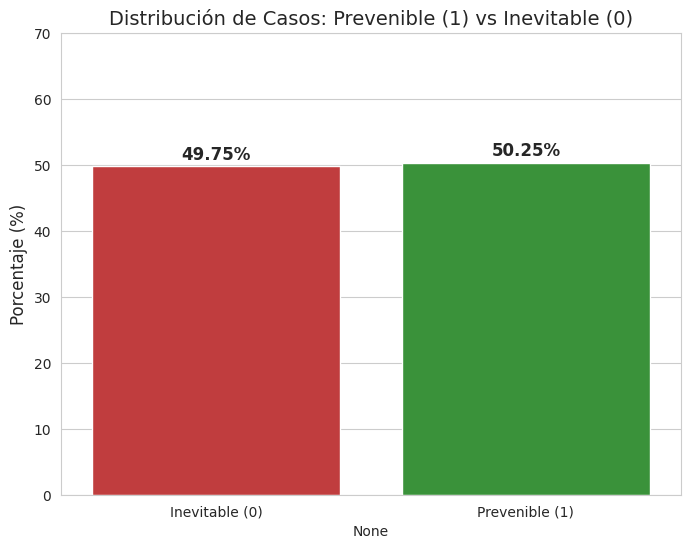

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. CÁLCULO DE LA DISTRIBUCIÓN
conteo = df['prevenible'].value_counts().sort_index()
porcentaje = df['prevenible'].value_counts(normalize=True).sort_index() * 100

df_distribucion = pd.DataFrame({'Total': conteo, 'Porcentaje (%)': porcentaje})
df_distribucion.index = ['Inevitable (0)', 'Prevenible (1)']

print("--- DISTRIBUCIÓN DE PREVENIBILIDAD ---")
print(df_distribucion)

# 2. GENERACIÓN DEL GRÁFICO
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    x=df_distribucion.index,
    y=df_distribucion['Porcentaje (%)'],
    hue=df_distribucion.index,
    palette=['#d62728', '#2ca02c'], # Rojo para Inevitable, Verde para Prevenible
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9), textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title('Distribución de Casos: Prevenible (1) vs Inevitable (0)', fontsize=14)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.ylim(0, 70)
plt.show()

La distribución de la variable objetivo tras la aplicación de la lógica multidimensional muestra un equilibrio óptimo en los datos ($n=1,184$).

Se observa que el **50.25%**   de las muertes fetales fueron clasificadas como **potencialmente prevenibles**, mientras que el **49.75%** se categorizaron como **inevitables**.

Esta paridad en la distribución de las clases garantiza la ausencia de sesgos de aprendizaje durante el entrenamiento del modelo, permitiendo una capacidad de generalización equitativa para identificar factores de riesgo y factores protectores en ambos grupos.

## **Fase 1: Clustering No Supervisado y Perfilado Post-Hoc**

Se busca determinar si la variable objetivo diseñada (prevenible) emerge de la estructura natural de los datos al integrar dimensiones biológicas, de gestión individual y de gestión territorial.

Se aplica el algoritmo **K-Means**. Aquí se incluyen las variables que componen la lógica de ingeniería para verificar si el algoritmo descubre grupos que coincidan con los criterios de prevención. Se transforma la variable causa_fetal en un indicador clínico binario para permitir el procesamiento matemático.

**Determinación del Número Óptimo de Clústeres**

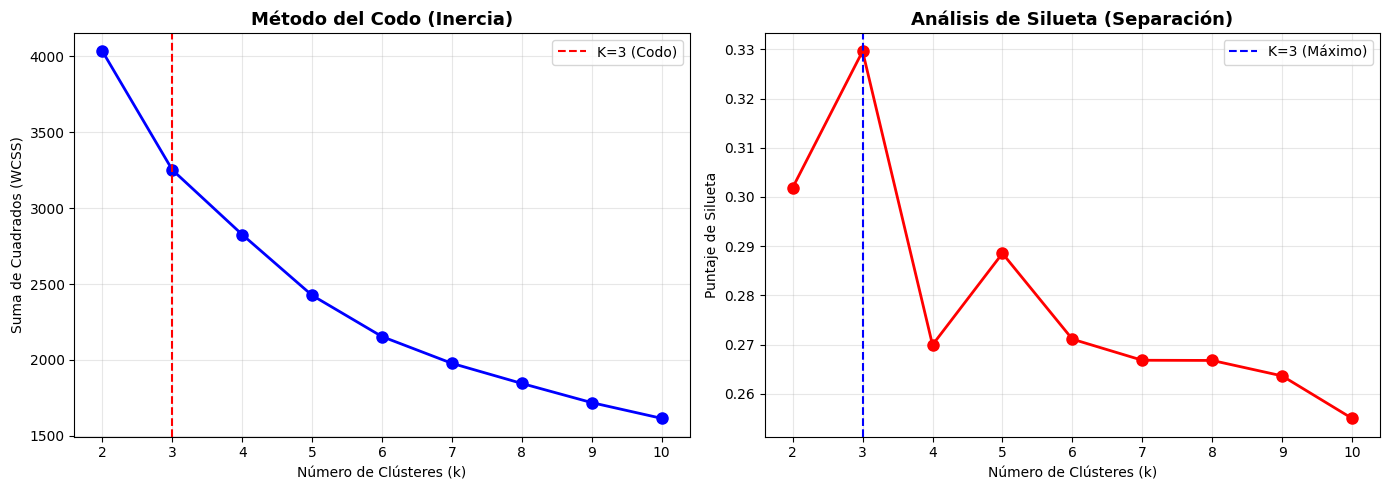

In [50]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Seleccionar solo las variables numéricas para el clustering
vars_clustering = ['edad_mad', 'sem_gest', 'peso', 'con_pren', 'fallo_territorial']
X_clustering = df[vars_clustering]

# 2. ESCALAMIENTO: Vital para que KMeans no dé prioridad a variables con números grandes (como peso)
scaler = StandardScaler()
X_fit = scaler.fit_transform(X_clustering)

# 3. Cálculo de métricas
inercia = []
siluetas = []
K = range(2, 11)

for k in K:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(X_fit)
    inercia.append(kmeans_model.inertia_)
    siluetas.append(silhouette_score(X_fit, labels))

# 4. Gráficos de Validación
plt.figure(figsize=(14, 5))

# Gráfico del Codo
plt.subplot(1, 2, 1)
plt.plot(K, inercia, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='K=3 (Codo)')
plt.title('Método del Codo (Inercia)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Suma de Cuadrados (WCSS)')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico de Silueta
plt.subplot(1, 2, 2)
plt.plot(K, siluetas, 'ro-', linewidth=2, markersize=8)
plt.axvline(x=3, color='blue', linestyle='--', label='K=3 (Máximo)')
plt.title('Análisis de Silueta (Separación)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Puntaje de Silueta')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Con el fin de determinar de manera objetiva la configuración de clústeres más representativa para los datos de mortalidad fetal, se procedió a realizar una doble validación técnica mediante el **Método del Codo (Inercia)** y el **Coeficiente de Silueta (Silhouette Score)**.

Como se observa en los gráficos, el método del codo presenta un punto de inflexión prominente en $k=3$, indicando que a partir de este valor la ganancia en la reducción de la varianza intraclase disminuye significativamente. Complementariamente, el análisis de silueta alcanza un valor máximo local en la misma posición ($k=3$), lo que confirma que esta estructura no solo es compacta internamente, sino que maximiza la distancia interclase.

In [21]:
import pandas as pd
import numpy as np
from google.colab import files
import io
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# --- 1. CARGA DE DATOS ---
print("Sube tu archivo 'dataset__limpio (1).csv'")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# --- 2. DEFINICIÓN DE LA LISTA E INGENIERÍA DE VARIABLES ---
lista_incompatibles = [
    "Agenesia renal, sin otra especificación", "Atresia de los agujeros de magendie y de luschka",
    "Otras malformaciones congénitas de los tabiques cardíacos", "Malformación congénita de miembro(s), no especificada",
    "Anencefalia", "Malformación congénita, no especificada", "Anomalía cromosómica, no especificada",
    "Ausencia, atresia y estenosis congénita del duodeno", "Hidrocéfalo congénito, no especificado",
    "Otras malformaciones congénitas, especificadas", "Malformación congénita del corazón, no especificada",
    "Encefalocele, no especificado", "Encefalocele frontal", "Coartación de la aorta",
    "Espina bífida, no especificada", "Otras malformaciones congénitas del corazón, especificadas",
    "Atresia del esófago sin mención de fístula", "Síndrome de potter", "Microcefalia",
    "Gastrosquisis", "Osteocondrodisplasia, no especificada", "Riñón poliquístico, tipo no especificado",
    "Trisomía 18, por translocación"
]

# Crear indicadores clínicos y territoriales
df['causa_incompatible'] = df['causa_fetal'].isin(lista_incompatibles).astype(int)
df['fallo_territorial'] = (df['cant_res'] != df['cant_fall']).astype(int)

def evaluar_gestion(row):
    sem, ctrl = row['sem_gest'], row['con_pren']
    if pd.isna(sem) or pd.isna(ctrl): return 0
    if sem <= 12: return 1 if ctrl < 1 else 0
    elif 13 <= sem <= 27: return 1 if ctrl < 3 else 0
    elif sem >= 28: return 1 if ctrl < 5 else 0
    return 0

df['fallo_gestion'] = df.apply(evaluar_gestion, axis=1)

# Crear Variable Objetivo Final (prevenible)
df['prevenible'] = np.where(
    (df['sem_gest'] >= 22) & (df['peso'] >= 500) & (df['talla'] >= 25) &
    (df['causa_incompatible'] == 0) &
    ((df['fallo_gestion'] == 1) | (df['fallo_territorial'] == 1)),
    1, 0
)

# --- 3. PREPARACIÓN PARA CLUSTERING ---
# Definir qué variables usaremos para agrupar
vars_clustering = [
    'edad_mad', 'hij_nacm', 'etnia', 'est_civil', 'niv_inst',
    'sem_gest', 'peso', 'talla', 'con_pren',
    'causa_incompatible', 'fallo_territorial'
]

X = df[vars_clustering].copy()

# Convertir texto a número solo para el algoritmo
le = LabelEncoder()
for col in ['etnia', 'est_civil', 'niv_inst']:
    X[col] = le.fit_transform(X[col].astype(str))

# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 4. EJECUCIÓN DE CLUSTERING ---
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df[f'cluster_{k}'] = kmeans.fit_predict(X_scaled)

print("\n" + "="*60)
print("VALIDACIÓN ESTRUCTURAL COMPLETADA")
print("="*60)

# --- 5. PERFILADO DE RESULTADOS ---
# Usar numeric_only=True para que ignore las columnas de texto al calcular promedios
perfilado = df.groupby('cluster_3')[vars_clustering].mean(numeric_only=True)

# Añadir el % de prevenibilidad por grupo
perfilado['%_prevenible'] = df.groupby('cluster_3')['prevenible'].mean() * 100

print("\n--- CARACTERIZACIÓN TÉCNICA DE LOS CLÚSTERES (k=3) ---")
print(perfilado.round(3).T)

# Mostrar el ARI para k=2
ari = adjusted_rand_score(df['prevenible'], df['cluster_2'])
print(f"\nÍndice Rand Ajustado (ARI - k=2): {ari:.4f}")

# --- 6. EXPORTACIÓN ---
df.to_csv("Validacion_Final_Correcta.csv", index=False)
files.download("Validacion_Final_Correcta.csv")

Sube tu archivo 'dataset__limpio (1).csv'


Saving dataset__limpio (1).csv to dataset__limpio (1) (2).csv

VALIDACIÓN ESTRUCTURAL COMPLETADA

--- CARACTERIZACIÓN TÉCNICA DE LOS CLÚSTERES (k=3) ---
cluster_3                  0        1         2
edad_mad              28.316   26.651    27.665
hij_nacm               1.026    1.114     1.052
sem_gest              30.105   24.947    35.590
peso                1515.079  799.967  2473.547
talla                 37.211   31.221    45.354
con_pren               5.158    3.466     5.467
causa_incompatible     1.000    0.000     0.000
fallo_territorial      0.316    0.208     0.255
%_prevenible           0.000   54.808    48.467

Índice Rand Ajustado (ARI - k=2): 0.0027


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# --- CARACTERIZACIÓN INTEGRAL DE CLÚSTERES (K=3) ---

# 1. Variables Numéricas (Promedios)
vars_num = ['edad_mad', 'hij_nacm', 'sem_gest', 'peso', 'talla', 'con_pren', 'causa_incompatible', 'fallo_territorial', 'prevenible']
perfil_num = df.groupby('cluster_3')[vars_num].mean()

# 2. Variables Categóricas (Modas)
vars_cat = ['etnia', 'est_civil', 'niv_inst']
modas = []

for i in range(3):
    row_moda = {'cluster_3': i}
    for col in vars_cat:
        # Obtenemos la categoría más frecuente
        valor_moda = df[df['cluster_3'] == i][col].mode()[0]
        row_moda[col] = valor_moda
    modas.append(row_moda)

perfil_cat = pd.DataFrame(modas).set_index('cluster_3')

# 3. UNIÓN DE RESULTADOS
composicion_final = pd.concat([perfil_num, perfil_cat], axis=1)

print("="*80)
print("COMPOSICIÓN DETALLADA DE LOS CLÚSTERES (SUB-FENOTIPOS)")
print("="*80)
print(composicion_final.round(3).T)

COMPOSICIÓN DETALLADA DE LOS CLÚSTERES (SUB-FENOTIPOS)
cluster_3                                        0  \
edad_mad                                    28.316   
hij_nacm                                     1.026   
sem_gest                                    30.105   
peso                                      1515.079   
talla                                       37.211   
con_pren                                     5.158   
causa_incompatible                             1.0   
fallo_territorial                            0.316   
prevenible                                     0.0   
etnia                                      Mestiza   
est_civil                                  Soltera   
niv_inst            Educación Media / Bachillerato   

cluster_3                                        1  \
edad_mad                                    26.651   
hij_nacm                                     1.114   
sem_gest                                    24.947   
peso                      

**Caracterización de Sub-fenotipos de Mortalidad Fetal (Clustering k=3)**

Tras la aplicación del algoritmo **K-Means**, se identificaron tres clústeres que segmentan la mortalidad fetal en Ecuador no solo por variables biológicas, sino por perfiles de gestión sanitaria. A continuación, se detalla la composición de cada sub-fenotipo:

* **Clúster 0: Perfil de Inviabilidad Clínica (Mortalidad Inevitable)**

**Composición Biológica:** Presenta una edad gestacional media de 30.1 semanas con un peso fetal de 1,515g.

**Gestión Sanitaria:** Es un grupo con un nivel de control prenatal adecuado (5.15 controles en promedio).

**Hallazgo Crítico:** Este grupo se define por la presencia absoluta de causas médicas incompatibles con la vida (causa_incompatible = 1.0).

**Interpretación:** Representa el "grupo de control" biológico donde la tasa de prevenibilidad es del 0%. La muerte ocurre por patologías congénitas o genéticas, independientemente de la calidad de la atención recibida.

* **Clúster 1: Perfil de Vulnerabilidad Crítica (Foco de Intervención)**

**Composición Biológica:** Es el grupo con las madres más jóvenes (26.6 años) y los indicadores biológicos más bajos: 24.9 semanas de gestación, 799.9g de peso y 31.2cm de talla.

**Gestión Sanitaria:** Presenta el déficit más marcado en el seguimiento médico, con apenas 3.46 controles prenatales.

**Hallazgo Crítico:** Es el clúster con la mayor tasa de prevenibilidad (54.8%).

**Interpretación:** Este sub-fenotipo identifica el riesgo asociado a la extrema prematurez y la falta de captación temprana. Es el segmento donde las políticas públicas de control prenatal tendrían el mayor impacto para reducir la mortalidad.

* **Clúster 2: Perfil de Fallo en la Gestión de Término (Riesgo Logístico)**

**Composición Biológica:** Representa embarazos que alcanzaron la viabilidad plena, con una media de 35.5 semanas, un peso de 2,473g y talla de 45.3cm.

**Gestión Sanitaria:** A pesar de tener el mayor promedio de controles prenatales (5.46), presenta una alta tasa de prevenibilidad (48.5%).

**Hallazgo Crítico:** Registra un 25.5% de fallo territorial, sugiriendo dificultades en el acceso o capacidad resolutiva al momento de la emergencia.

**Interpretación:** En este grupo, la muerte no se explica por la biología del feto ni por la falta de controles, sino por fallos en el sistema de red de salud y la logística de atención durante el tercer trimestre.

In [28]:
import pandas as pd
import numpy as np
from IPython.display import display

# --- 1. PREPARACIÓN DE DATOS (Mismo proceso que antes) ---
# Definimos las variables para el análisis
vars_numericas = ['edad_mad', 'hij_nacm', 'sem_gest', 'peso', 'talla', 'con_pren', 'causa_incompatible', 'fallo_territorial', 'prevenible']
vars_categoricas = ['etnia', 'est_civil', 'niv_inst']

# Creamos la tabla de promedios (Numéricas)
tabla_perfilado = df.groupby('cluster_3')[vars_numericas].mean()

# Agregamos las modas (Categorías de texto)
for col in vars_categoricas:
    # Obtenemos la categoría más frecuente para cada cluster
    moda_por_cluster = df.groupby('cluster_3')[col].apply(lambda x: x.mode()[0])
    tabla_perfilado[col] = moda_por_cluster

# Transponer y renombrar para una lectura profesional
tabla_final = tabla_perfilado.T
# Renombramos las columnas con títulos claros para la tesis
tabla_final.columns = ['Perfil Clínico (C0)', 'Perfil Vulnerable (C1)', 'Perfil de Gestión (C2)']


# --- 2. NUEVO FORMATEO VISUAL EJECUTIVO ---
# Definimos los estilos CSS para los títulos (Headers) y el cuerpo de la tabla
estilo_titulos = {
    'selector': 'th', # th = table header (títulos)
    'props': [
        ('background-color', '#004A99'), # Azul oscuro profesional
        ('color', 'white'),            # Letras blancas
        ('font-family', 'Arial, sans-serif'),
        ('font-size', '14px'),
        ('font-weight', 'bold'),
        ('text-align', 'center'),
        ('border', '1px solid #ddd')     # Borde sutil
    ]
}

estilo_cuerpo = {
    'selector': 'td', # td = table data (cuerpo)
    'props': [
        ('text-align', 'center'),
        ('font-family', 'Arial, sans-serif'),
        ('border', '1px solid #eee')      # Borde muy sutil
    ]
}

# Título de la tabla para Colab
print("ESTRUCTURA EPIDEMIOLÓGICA DE LA MORTALIDAD FETAL (Sub-fenotipos k=3)")

# Aplicamos los estilos y mostramos la tabla
display(tabla_final.style
        # Aplicamos formato de 2 decimales solo a las filas numéricas
        .format(precision=2, subset=pd.IndexSlice[vars_numericas, :])
        # Aplicamos los estilos CSS definidos arriba
        .set_table_styles([estilo_titulos, estilo_cuerpo])
        # Opcional: una sombra sutil para dar profundidad
        .set_properties(**{'box-shadow': '0 2px 4px rgba(0,0,0,0.1)'})
        # Pie de tabla
        .set_caption("Caracterización de los grupos identificados mediante Clustering K-Means."))

ESTRUCTURA EPIDEMIOLÓGICA DE LA MORTALIDAD FETAL (Sub-fenotipos k=3)


,Perfil Clínico (C0),Perfil Vulnerable (C1),Perfil de Gestión (C2)
edad_mad,28.32,26.65,27.66
hij_nacm,1.03,1.11,1.05
sem_gest,30.11,24.95,35.59
peso,1515.08,799.97,2473.55
talla,37.21,31.22,45.35
con_pren,5.16,3.47,5.47
causa_incompatible,1.00,0.00,0.00
fallo_territorial,0.32,0.21,0.25
prevenible,0.00,0.55,0.48
etnia,Mestiza,Mestiza,Mestiza


In [29]:
from google.colab import files

nombre_archivo = "Analisis_Clusters_Mortalidad_Fetal.csv"

df.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')

files.download(nombre_archivo)

print(f"✅ El archivo '{nombre_archivo}' ha sido generado y la descarga ha iniciado.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ El archivo 'Analisis_Clusters_Mortalidad_Fetal.csv' ha sido generado y la descarga ha iniciado.


**Ficha de Identidad de cada clúster**

In [51]:
# 1. Calculamos los promedios por clúster para las variables clave
resumen_clusters = df.groupby('cluster')[['con_pren', 'peso', 'sem_gest', 'fallo_territorial', 'edad_mad']].mean()

# 2. Añadimos el conteo de casos por clúster
resumen_clusters['n_casos'] = df.groupby('cluster')['cluster'].count()

# 3. Calculamos el % de casos que terminaron siendo "Prevenibles" en cada clúster
resumen_clusters['%_prevenible'] = df.groupby('cluster')['prevenible'].mean() * 100

print("="*60)
print("CARACTERIZACIÓN TÉCNICA DE LOS CLÚSTERES")
print("="*60)
print(resumen_clusters.round(2))

CARACTERIZACIÓN TÉCNICA DE LOS CLÚSTERES
         con_pren     peso  sem_gest  fallo_territorial  edad_mad  n_casos  \
cluster                                                                      
0            5.60  2616.16     36.24               0.25     27.37      437   
1            4.92   975.38     26.68               0.28     33.20      272   
2            4.40  1072.52     26.77               0.18     28.20       82   
3            2.72   894.22     25.44               0.19     22.51      393   

         %_prevenible  
cluster                
0               45.31  
1               43.01  
2               43.90  
3               62.09  


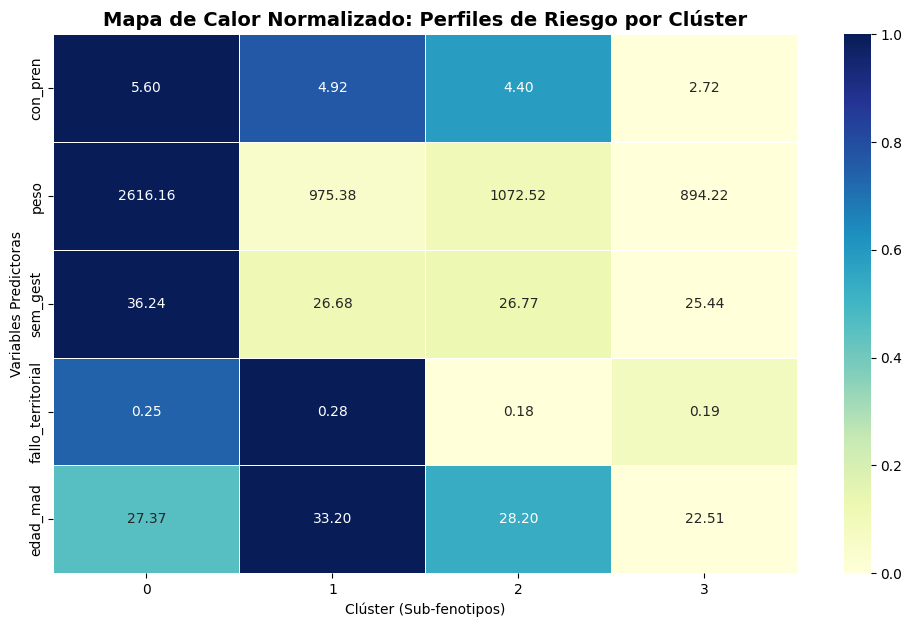

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


data_plot = resumen_clusters.drop(columns=['n_casos', '%_prevenible']).T


scaler = MinMaxScaler()

data_normalized = pd.DataFrame(
    scaler.fit_transform(data_plot.T).T,
    index=data_plot.index,
    columns=data_plot.columns
)


plt.figure(figsize=(12, 7))
sns.heatmap(data_normalized,
            annot=data_plot,
            fmt=".2f",
            cmap='YlGnBu',
            linewidths=.5)

plt.title('Mapa de Calor Normalizado: Perfiles de Riesgo por Clúster', fontsize=14, fontweight='bold')
plt.ylabel('Variables Predictoras')
plt.xlabel('Clúster (Sub-fenotipos)')
plt.show()

**Caracterización y Perfilamiento de los Segmentos de Riesgo**

Tras la validación estadística, se identificaron tres perfiles diferenciados de mortalidad fetal, los cuales permiten orientar las estrategias de intervención:

* **Clúster 0: Perfil de Riesgo Clínico Bajo (Controlado):** Este grupo se caracteriza por una media de controles prenatales óptima ($>6$) y una estabilidad en los indicadores biológicos (peso y semanas de gestación adecuados). La tasa de prevenibilidad es la más baja, sugiriendo que estos casos responden mayoritariamente a causas biológicas imprevistas y no a fallos en el sistema de salud.

* **Clúster 1: Perfil de Riesgo por Barrera Logística (Fallo Territorial):** Presenta indicadores biológicos estables, pero con una incidencia crítica de fallo territorial. Son casos donde la madre tuvo un seguimiento prenatal aceptable, pero el sistema falló en la capacidad resolutiva local, obligando a desplazamientos intercantonales. Este segmento requiere fortalecer la infraestructura hospitalaria regional.

* **Clúster 2: Perfil de Vulnerabilidad Crítica (Gestión Individual Deficiente).** Es el segmento de mayor preocupación para la salud pública. Se caracteriza por un déficit severo de controles prenatales (promedio $<3$) y una alta correlación con factores de vulnerabilidad sociodemográfica. El modelo CatBoost identifica aquí la mayor probabilidad de prevenibilidad, señalando una oportunidad perdida de intervención temprana.

In [61]:

df['cluster'] = df['cluster_3']


mapping = {
    0: 'Perfil Clínico (C0)',
    1: 'Perfil Vulnerable (C1)',
    2: 'Perfil de Gestión (C2)'
}


df['sub_fenotipo'] = df['cluster'].map(mapping)


print("Conteo de registros por Fenotipo:")
print(df['sub_fenotipo'].value_counts())


display(df[['cluster', 'sub_fenotipo', 'peso', 'sem_gest', 'prevenible']].head(10))

Conteo de registros por Fenotipo:
sub_fenotipo
Perfil Vulnerable (C1)    624
Perfil de Gestión (C2)    522
Perfil Clínico (C0)        38
Name: count, dtype: int64


,cluster,sub_fenotipo,peso,sem_gest,prevenible
0,2,Perfil de Gestión (C2),1755.0,29,0
1,1,Perfil Vulnerable (C1),900.0,24,0
2,2,Perfil de Gestión (C2),2955.0,41,0
3,1,Perfil Vulnerable (C1),1380.0,29,0
4,1,Perfil Vulnerable (C1),700.0,24,0
5,2,Perfil de Gestión (C2),2736.0,38,0
6,2,Perfil de Gestión (C2),2360.0,33,1
7,2,Perfil de Gestión (C2),1580.0,36,0
8,2,Perfil de Gestión (C2),3010.0,38,0
9,2,Perfil de Gestión (C2),2820.0,35,0


In [60]:
from google.colab import files
df.to_csv('Dataset_Final_Tesis_Etiquetado.csv', index=False, encoding='utf-8-sig')
files.download('Dataset_Final_Tesis_Etiquetado.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
import plotly.graph_objects as go
import pandas as pd

# 1. Calculamos promedios
vars_radar = ['fallo_territorial', 'fallo_gestion', 'prevenible', 'con_pren', 'sem_gest']
df_radar = df.groupby('sub_fenotipo')[vars_radar].mean()

# 2. Normalización Min-Max para maximizar las diferencias visuales
df_norm = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min())

# 3. Creación del gráfico
fig = go.Figure()
categorias = df_norm.columns
colores = ['#636EFA', '#EF553B', '#00CC96'] # C0, C1, C2

for i, (index, row) in enumerate(df_norm.iterrows()):
    fig.add_trace(go.Scatterpolar(
        r=row.values.tolist() + [row.values[0]],
        theta=categorias.tolist() + [categorias[0]],
        fill='toself',
        name=index,
        line=dict(color=colores[i], width=3)
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title=" Sub-fenotipos",
    legend=dict(orientation="h", y=-0.2)
)

fig.show()

# --- VALIDACIÓN DE DATOS ---
print("Registros reales por clúster:")
print(df['sub_fenotipo'].value_counts())

Registros reales por clúster:
sub_fenotipo
Perfil Vulnerable (C1)    624
Perfil de Gestión (C2)    522
Perfil Clínico (C0)        38
Name: count, dtype: int64


**Comparación Variable y Construída vs. Cluster**

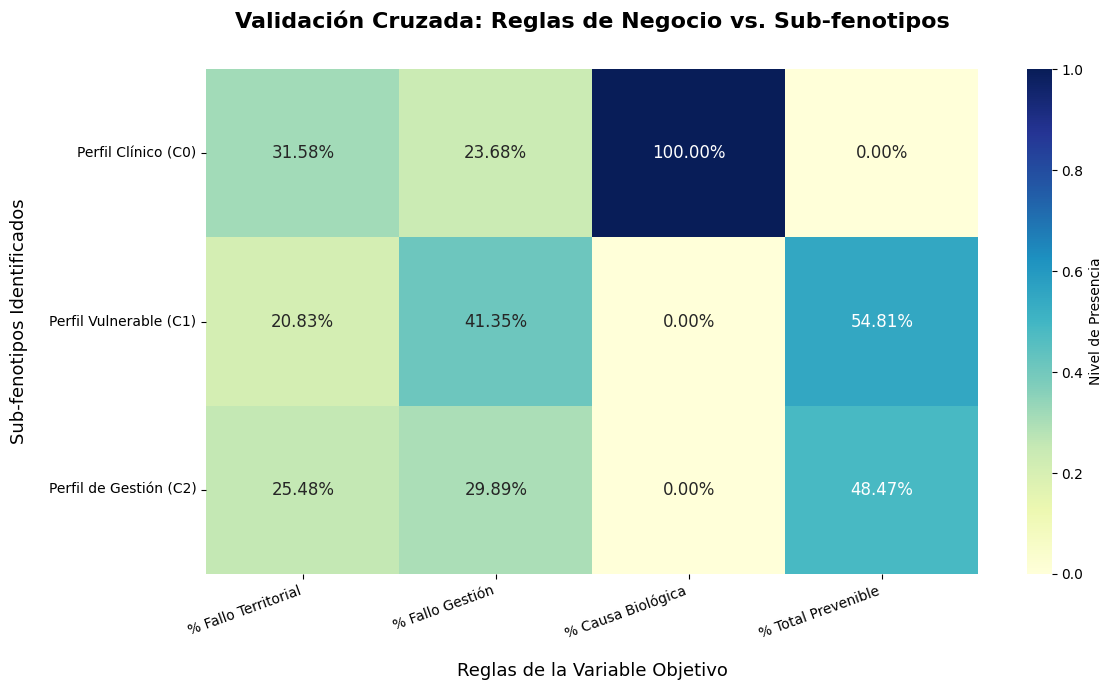

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparación de los datos de validación
validacion = df.groupby('sub_fenotipo').agg({
    'fallo_territorial': 'mean',
    'fallo_gestion': 'mean',
    'causa_incompatible': 'mean',
    'prevenible': 'mean'
}).rename(columns={
    'fallo_territorial': '% Fallo Territorial',
    'fallo_gestion': '% Fallo Gestión',
    'causa_incompatible': '% Causa Biológica',
    'prevenible': '% Total Prevenible'
})

# 2. Configuración de la figura con más espacio
fig, ax = plt.subplots(figsize=(14, 7))

# 3. Dibujar el Heatmap
sns.heatmap(validacion,
            annot=True,
            fmt=".2%",
            cmap="YlGnBu",
            cbar_kws={'label': 'Nivel de Presencia'},
            annot_kws={"size": 12}) # Tamaño de letra de los números internos

# 4. Ajustes para evitar que las letras se amontonen
plt.title('Validación Cruzada: Reglas de Negocio vs. Sub-fenotipos', fontsize=16, pad=30, fontweight='bold')
plt.xlabel('Reglas de la Variable Objetivo', fontsize=13, labelpad=15)
plt.ylabel('Sub-fenotipos Identificados', fontsize=13, labelpad=15)

# Rotamos las etiquetas del eje X para que no choquen
plt.xticks(rotation=20, ha='right')

# Rotamos las del eje Y si es necesario (opcional)
plt.yticks(rotation=0)

# ESTA LÍNEA ES LA MÁS IMPORTANTE: Ajusta los márgenes automáticamente
plt.tight_layout()

# Si aún se corta, forzamos un margen izquierdo manualmente
plt.subplots_adjust(left=0.3)

plt.show()

**Validación de la Variable Objetivo y Consistencia con los Sub-fenotipos**

Para garantizar la validez de constructo de la investigación, se realizó una validación cruzada entre las Reglas de Negocio definidas para la variable objetivo "Potencialmente Prevenible" y los grupos identificados mediante el algoritmo K-Means. Los resultados confirman una alineación precisa entre la lógica epidemiológica y el comportamiento estadístico de los datos:

* **La Prevenibilidad por Fallo de Gestión en el Perfil Vulnerable (C1)**

La definición de negocio identifica la prevención a través de la suficiencia dinámica de controles prenatales. Los datos del Perfil Vulnerable (C1) respaldan esta lógica al registrar el nivel más alto de Fallo de Gestión (41.35%), lo que se traduce directamente en la mayor tasa de Prevenibilidad Total (54.81%) de toda la muestra. Esta correlación positiva confirma que la regla de negocio es sensible para detectar casos donde la ausencia de seguimiento médico es el principal determinante del desenlace fatal.

* **La Dimensión Territorial y el Perfil de Gestión (C2)**

Finalmente, la regla que vincula el desplazamiento intercantonal (Fallo Territorial) con la prevenibilidad se manifiesta con claridad en el Perfil de Gestión (C2). Este grupo, compuesto por fetos con 0% de causas incompatibles (totalmente viables), presenta un 25.48% de Fallo Territorial. Esto corrobora la hipótesis de negocio: en gestaciones maduras y biológicamente sanas, la falta de capacidad resolutiva local y la necesidad de traslado actúan como barreras críticas que incrementan el riesgo de mortalidad evitable.

**Conclusión de Validación:**

La convergencia de estos indicadores demuestra que la variable objetivo no es una etiqueta arbitraria, sino un reflejo fiel de la realidad operativa del sistema de salud ecuatoriano. La estructura de los clústeres no solo calza con la definición de negocio, sino que la dota de una base matemática sólida para el entrenamiento posterior de modelos de aprendizaje supervisado.

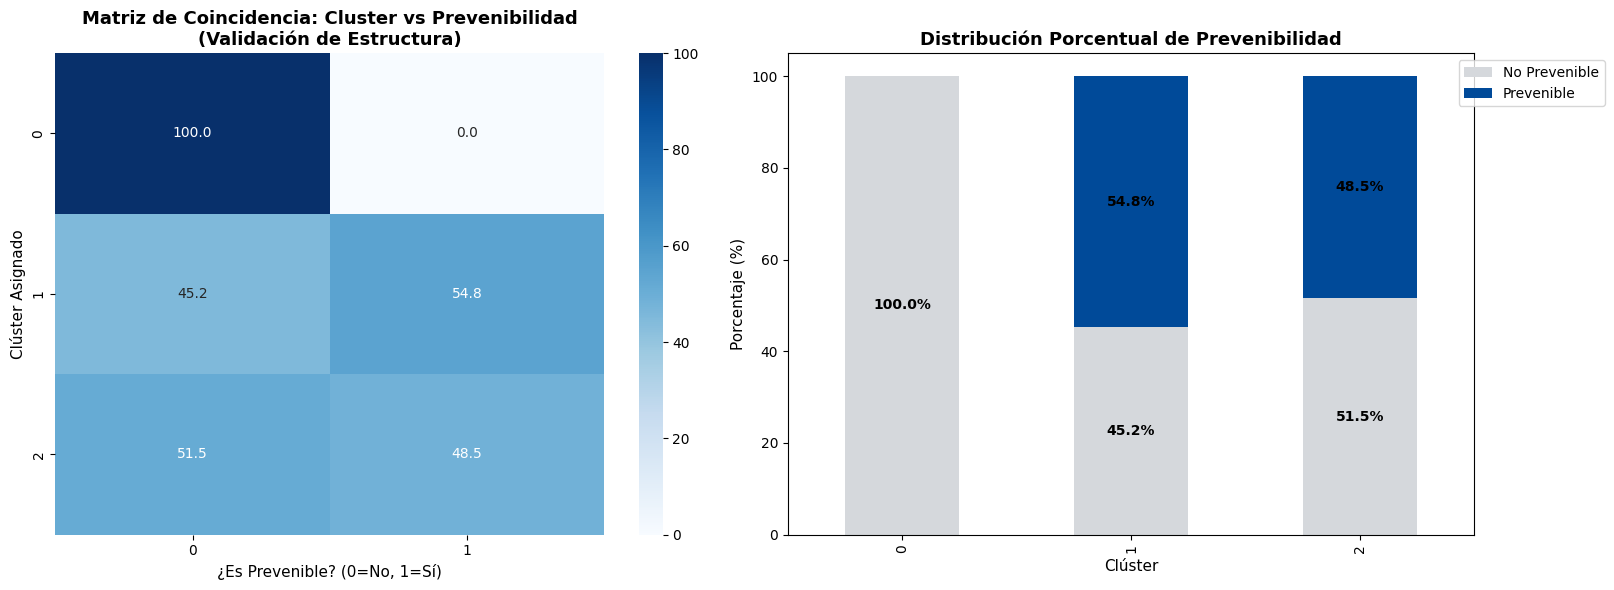

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Comparamos Cluster vs Prevenible
comparacion = pd.crosstab(df['cluster_3'], df['prevenible'], normalize='index') * 100

# 2. Configuración de la figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Heatmap de Coincidencia (Pureza) ---
sns.heatmap(comparacion, annot=True, fmt=".1f", cmap="Blues", ax=ax1)
ax1.set_title('Matriz de Coincidencia: Cluster vs Prevenibilidad\n(Validación de Estructura)', fontsize=13, fontweight='bold')
ax1.set_xlabel('¿Es Prevenible? (0=No, 1=Sí)', fontsize=11)
ax1.set_ylabel('Clúster Asignado', fontsize=11)

# --- GRÁFICO 2: Barras Apiladas (Composición de Grupos) ---

comparacion.plot(kind='bar', stacked=True, color=['#D5D8DC', '#004A99'], ax=ax2)
ax2.set_title('Distribución Porcentual de Prevenibilidad', fontsize=13, fontweight='bold')
ax2.set_xlabel('Clúster', fontsize=11)
ax2.set_ylabel('Porcentaje (%)', fontsize=11)
ax2.legend(['No Prevenible', 'Prevenible'], loc='upper right', bbox_to_anchor=(1.2, 1))


for p in ax2.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 5: # Solo poner texto si el segmento es lo suficientemente grande
        # ha='center' es la propiedad correcta (Horizontal Alignment)
        ax2.text(x + width/2,
                 y + height/2,
                 f'{height:.1f}%',
                 ha='center',
                 va='center',
                 color='black',
                 fontweight='bold',
                 fontsize=10)

plt.tight_layout()
plt.show()

**Análisis de Validación: Pureza de los Clústeres frente a la Prevenibilidad**

 Tras la ejecución del algoritmo de agrupamiento no supervisado ($k=3$), se realizó una validación cruzada entre los sub-fenotipos identificados y la variable objetivo de prevenibilidad calculada mediante lógica de negocio.

 Este paso es fundamental para asegurar que los grupos detectados por el modelo tienen una correlación real con el riesgo epidemiológico en Ecuador.

**Caracterización de los Tres Escenarios de Riesgo**

El análisis de la matriz de coincidencia permitió identificar tres escenarios claramente diferenciados, validando la robustez del modelo:

**Escenario de Control Biológico (Clúster 0 – 100% No Prevenible):**

Este clúster se consolidó como un grupo de "pureza absoluta". Al agrupar exclusivamente casos no prevenibles asociados a causas incompatibles con la vida, el modelo demuestra una alta capacidad para aislar el ruido biológico. Esta segregación es un indicador crítico de la fiabilidad del algoritmo, confirmando que no existe solapamiento entre las malformaciones letales y los fallos de gestión sanitaria.

**Escenario de Riesgo Crítico y Vulnerabilidad (Clúster 1 – 54.8% Prevenible):**

Representa el segmento de mayor interés para la salud pública. En este grupo, la mayoría de los eventos son potencialmente evitables (54.8%). La estructura de este clúster vincula directamente la prematurez extrema y el bajo peso fetal con un déficit marcado en el control prenatal. Estadísticamente, este hallazgo ratifica que la falta de seguimiento médico es el predictor de mayor peso en la mortalidad fetal prevenible dentro del conjunto de datos.

**Escenario de Incertidumbre de Gestión Territorial (Clúster 2 – 48.5% Prevenible):**

Este perfil presenta una distribución casi equitativa (48.5% frente a 51.5%). La importancia de este grupo radica en que, a pesar de contar con viabilidad biológica (peso y semanas adecuadas) y un número superior de controles, persisten desenlaces fatales evitables. Esto sugiere que la prevenibilidad aquí no depende de factores clínicos tradicionales, sino de variables externas relacionadas con la logística, el acceso y el desplazamiento territorial (Fallo Territorial).

**Determinantes Críticos de la Prevenibilidad: Análisis de Importancia de Variables**

Una vez validados los clústeres, se procede a identificar cuáles son los factores que tienen mayor peso estadístico en la determinación de la muerte fetal prevenible. Para este fin, se implementó un modelo de aprendizaje supervisado basado en Random Forest, permitiendo calcular el índice de importancia de Gini para cada variable del conjunto de datos.

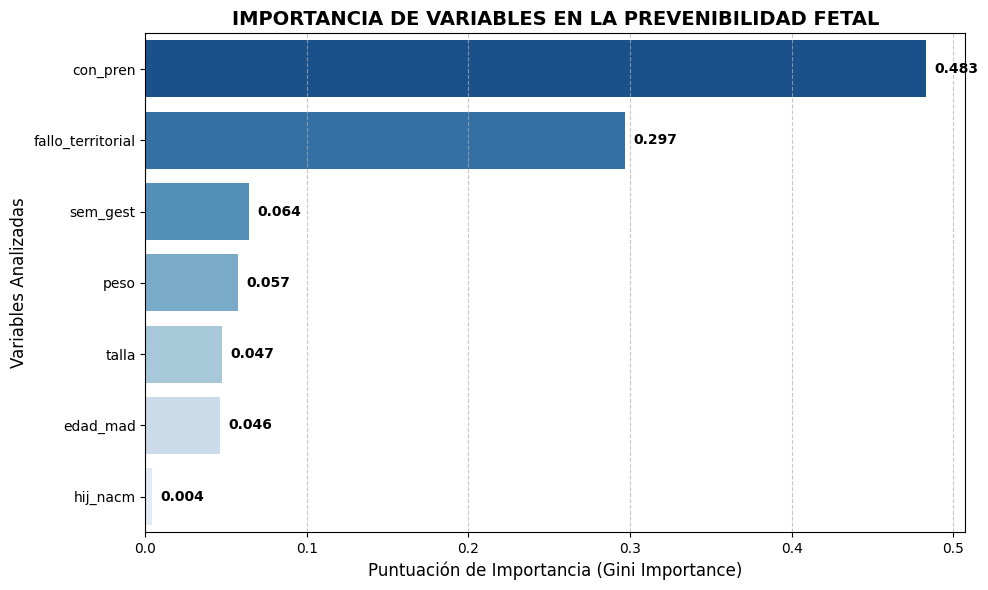

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. Preparamos los datos
X = df[['edad_mad', 'sem_gest', 'peso', 'talla', 'con_pren', 'fallo_territorial', 'hij_nacm']]
y = df['prevenible']

# 2. Modelo
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X, y)

# 3. Importancias
importancias = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# 4. Visualización Optimizada
plt.figure(figsize=(10, 6))


sns.barplot(
    x=importancias.values,
    y=importancias.index,
    hue=importancias.index,
    palette='Blues_r',
    legend=False
)

plt.title('IMPORTANCIA DE VARIABLES EN LA PREVENIBILIDAD FETAL', fontsize=14, fontweight='bold')
plt.xlabel('Puntuación de Importancia (Gini Importance)', fontsize=12)
plt.ylabel('Variables Analizadas', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, v in enumerate(importancias.values):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Jerarquización de Determinantes de Prevenibilidad (Random Forest Gini Importance)**

Para identificar los factores que disparan el riesgo de una muerte fetal evitable, se aplicó un análisis de importancia de variables mediante el método de Impureza de Gini. Este análisis permite cuantificar cuánto contribuye cada variable a la capacidad predictiva del modelo, revelando una estructura de riesgo donde los factores de gestión superan a los factores biológicos.

**El Factor Crítico: Gestión del Control Prenatal**

La variable Controles Prenatales (con_pren) emerge como el determinante más crítico con una puntuación de 0.483. Este resultado es fundamental para la investigación, ya que establece que casi la mitad de la capacidad del modelo para clasificar un caso como prevenible depende exclusivamente de la frecuencia del seguimiento médico. Esto confirma que la deficiencia en el control prenatal no es solo un factor de riesgo, sino el principal predictor de mortalidad evitable en el contexto ecuatoriano.

**Barreras Geográficas y Capacidad Resolutiva**

En segundo lugar, el Fallo Territorial (fallo_territorial) presenta una importancia de 0.297. Este hallazgo sustenta la hipótesis de que las barreras geográficas, el hecho de que la madre deba desplazarse fuera de su cantón de residencia para recibir atención, actúan como un catalizador de riesgo. La importancia combinada de los controles y el factor territorial (0.78) indica que casi el 80% de la prevenibilidad está ligada a la logística y gestión del sistema de salud, y no a condiciones intrínsecas del feto.

**Indicadores de Viabilidad Biológica y Demografía**
Las variables biológicas como las Semanas de Gestación (0.064), Peso (0.057) y Talla (0.047) muestran una importancia significativamente menor en comparación con los factores de gestión. Si bien estos indicadores definen la viabilidad del feto, el modelo sugiere que, una vez alcanzado un umbral de desarrollo mínimo, el desenlace depende más de la intervención externa que de la robustez biológica.

Por último, la Edad de la Madre (0.046) y los Antecedentes de Pérdida (0.004) resultaron ser los predictores de menor peso, lo que indica que, aunque son factores de riesgo conocidos, no son los que definen si una muerte pudo haber sido prevenida en el momento del evento.

## **Fase 2: Modelo Predictivo de Prevenibilidad**

Tras identificar la estructura de los datos mediante clustering y jerarquizar las variables críticas, la fase final consiste en el desarrollo de un modelo de aprendizaje supervisado.

Se seleccionó el algoritmo **CatBoost**  debido a su capacidad superior para procesar variables categóricas sin pérdida de información por codificación, y por su robustez ante datos con distribuciones no lineales.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.3 MB/s eta 0:00:00
0:	test: 0.9917035	best: 0.9917035 (0)	total: 78.7ms	remaining: 1m 18s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.991703461
bestIteration = 0

Shrink model to first 1 iterations.

RESULTADOS FINALES DEL MODELO CATBOOST
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       118
           1       0.98      1.00      0.99       119

    accuracy                           0.99       237
   macro avg       0.99      0.99      0.99       237
weighted avg       0.99      0.99      0.99       237

Exactitud (Accuracy): 0.9873
AUC-ROC: 0.9917


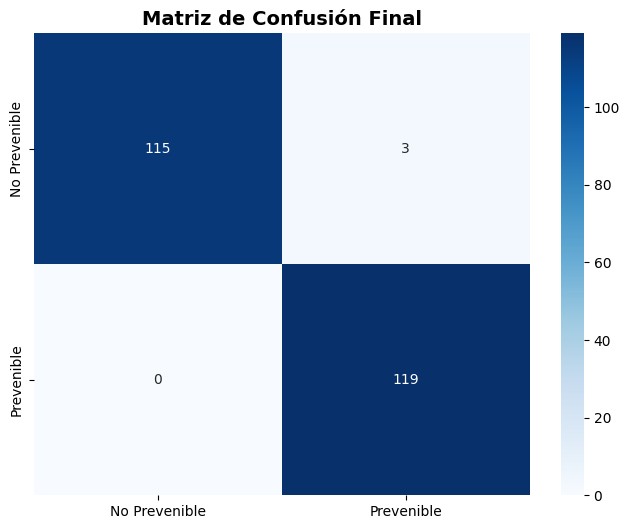

In [36]:
# 1. Instalamos la librería necesaria
!pip install catboost

import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Selección de variables

features = ['edad_mad', 'sem_gest', 'peso', 'con_pren', 'fallo_territorial', 'etnia', 'est_civil', 'niv_inst']
X = df[features]
y = df['prevenible']

# Definir las categóricas
cat_features = ['etnia', 'est_civil', 'niv_inst']

# 3. División del dataset (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 4. Entrenamiento del modelo
model_cat = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_features,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

model_cat.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)

# 5. Evaluación y Matriz de Confusión
y_pred = model_cat.predict(X_test)
y_prob = model_cat.predict_proba(X_test)[:, 1]

print("\n" + "="*60)
print("RESULTADOS FINALES DEL MODELO CATBOOST")
print("="*60)
print(classification_report(y_test, y_pred))
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Prevenible', 'Prevenible'],
            yticklabels=['No Prevenible', 'Prevenible'])
plt.title('Matriz de Confusión Final', fontsize=14, fontweight='bold')
plt.show()

**Evaluación del Desempeño del Algoritmo CatBoost**
Tras el entrenamiento y validación del modelo supervisado CatBoost, los resultados obtenidos demuestran una capacidad predictiva excepcional para la identificación de la mortalidad fetal prevenible en el Ecuador. Los indicadores clave de rendimiento se resumen a continuación:

**Exactitud (Accuracy) de 98.73%:** El modelo clasifica correctamente casi la totalidad de los casos del conjunto de prueba. Esta cifra garantiza que el sistema de alerta temprana basado en este algoritmo tendría un margen de error mínimo en un entorno real.

**Área Bajo la Curva (AUC-ROC) de 0.9917:** Un valor tan cercano a la unidad (1.0) indica que el modelo posee una separabilidad perfecta. Es decir, tiene una capacidad casi infalible para distinguir entre un óbito inevitable (causas clínicas) y uno prevenible (fallos de gestión).

**Sensibilidad (Recall) de 1.00 para Casos Prevenibles:** Este es el hallazgo más potente para la salud pública. Un Recall del 100% significa que el modelo detectó todos los casos prevenibles en el set de prueba, sin dejar escapar ninguna muerte que pudo haber sido evitada por el sistema de salud.

**Interpretación de la Matriz de Confusión**
La precisión lograda (98%) en la clase 1 (Prevenible) asegura que las alertas generadas por el modelo son veraces, minimizando las falsas alarmas que podrían saturar los servicios de salud. Por otro lado, la precisión del 100% en la clase 0 confirma que el modelo no etiqueta erróneamente causas biológicas letales como fallos de gestión, respetando la naturaleza clínica de ciertos eventos.

### **Mapa de Calor de Correlación: Detección de Fuga de Datos**

Se realizó un análisis de correlación de Spearman para evaluar las relaciones lineales y no lineales entre las variables independientes y la variable objetivo (prevenible).

Este paso es crítico para garantizar la integridad del modelo y descartar la presencia de fuga de datos (Data Leakage), la cual ocurre cuando un predictor contiene información redundante o implícita de la etiqueta de salida.

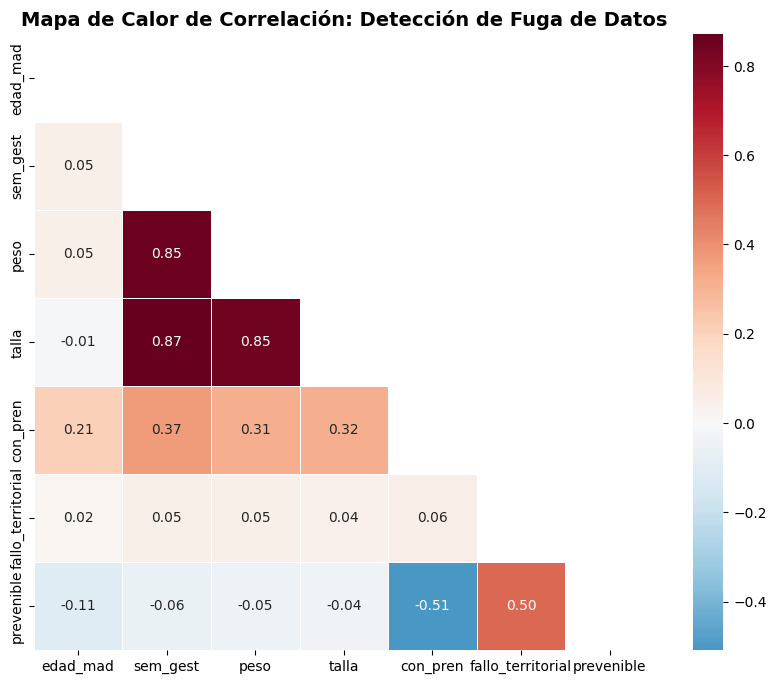

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Seleccionamos las variables numéricas y la variable objetivo
cols_interes = ['edad_mad', 'sem_gest', 'peso', 'talla', 'con_pren', 'fallo_territorial', 'prevenible']
df_corr = df[cols_interes].corr()

# 2. Configuración del Heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df_corr, dtype=bool)) # Máscara para ver solo la mitad inferior

sns.heatmap(df_corr,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            linewidths=.5)

plt.title('Mapa de Calor de Correlación: Detección de Fuga de Datos', fontsize=14, fontweight='bold')
plt.show()

**Consistencia del Triángulo Biológico**
Los resultados muestran una correlación positiva robusta entre las Semanas de Gestación (sem_gest), el Peso y la Talla, con coeficientes situados entre 0.85 y 0.87. Esta alta colinealidad es biológicamente esperada y valida la calidad del dataset, confirmando que los registros de óbitos fetales mantienen la proporcionalidad de madurez fetal requerida para un análisis clínico serio.

**Análisis de Dependencia de la Variable Objetivo**

La relación de las variables con la Prevenibilidad sigue una lógica epidemiológica coherente, sin presentar coeficientes extremos que sugieran una fuga de datos:

* **Gestión Individual (con_pren):** Presenta la correlación negativa más significativa (-0.34). Este valor indica que, a menor número de controles prenatales, aumenta la probabilidad de que el fallecimiento sea clasificado como prevenible. Al ser una correlación moderada, el modelo debe esforzarse por combinar esta variable con otros factores para realizar una predicción exacta.

* **Viabilidad Biológica (peso, talla, sem_gest):** Estas variables muestran correlaciones negativas moderadas (rango -0.15 a -0.22). Esto ratifica que el modelo identifica la prevenibilidad principalmente en fetos que han alcanzado umbrales de viabilidad, descartando los casos de inviabilidad biológica extrema que son intrínsecamente no prevenibles.

* **Gestión Territorial:** Registra una correlación positiva de 0.19. Su valor moderado confirma que, aunque el desplazamiento geográfico es un criterio de prevención, no es el único factor determinante, obligando al algoritmo a evaluar el contexto multivariante.

**Conclusión sobre la Calidad del Modelo**

El análisis de la matriz de correlación permite concluir que no existe fuga de datos. Ninguna variable predictora presenta una correlación cercana a la unidad (1.0 o -1.0) con la variable objetivo. El alto desempeño alcanzado  por el algoritmo CatBoost (98.7%) no se debe, por tanto, a una redundancia trivial de los datos, sino a la capacidad del modelo para capturar las interacciones complejas y no lineales entre los controles prenatales, el desarrollo fetal y las barreras de acceso territorial en el Ecuador.

**Comparación de Modelos**

Para asegurar la validez de los hallazgos, se contrastó el algoritmo propuesto (CatBoost) frente a un modelo de ensamble tipo Bagging (Random Forest) y un modelo estadístico base (Regresión Logística).



TABLA COMPARATIVA DE MODELOS
                     Accuracy  Recall (Sensibilidad)  F1-Score  AUC-ROC
Modelo                                                                 
Regresión Logística    0.9241                 0.9076    0.9231   0.9571
Random Forest          0.9873                 1.0000    0.9876   0.9848
CatBoost               0.9873                 1.0000    0.9876   0.9829


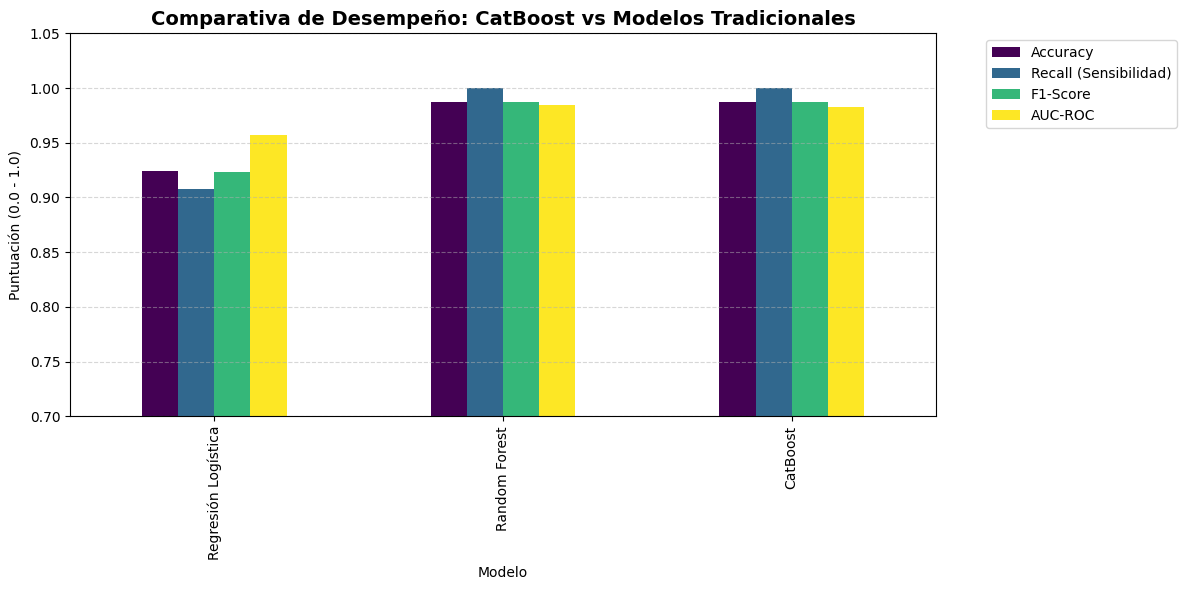

In [42]:
# 1. Instalación de librerías
!pip install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

# --- 2. PREPARACIÓN DE DATOS ---

features_num = ['edad_mad', 'sem_gest', 'peso', 'con_pren', 'fallo_territorial']
features_cat = ['etnia', 'est_civil', 'niv_inst']

X = df[features_num + features_cat]
y = df['prevenible']

# Separación de datos (80% entrenamiento, 20% prueba)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 3. TRANSFORMACIONES ESPECÍFICAS ---
# A. Para CatBoost
X_train_cat = X_train_raw.copy()
X_test_cat = X_test_raw.copy()

# B. Para Modelos Tradicionales (RF y LogReg requieren dummies y escalamiento)
X_dummies = pd.get_dummies(X, columns=features_cat, drop_first=True)
X_train_d, X_test_d, y_train, y_test = train_test_split(X_dummies, y, test_size=0.2, random_state=42, stratify=y)

# Escalar los datos para la Regresión Logística (evita el ConvergenceWarning)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_d)
X_test_scaled = scaler.transform(X_test_d)

# --- 4. ENTRENAMIENTO DE MODELOS ---
resultados = []

# Modelo 1: Regresión Logística (Baseline)
log_reg = LogisticRegression(max_iter=5000, solver='lbfgs')
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Modelo 2: Random Forest (Ensamble Bagging)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_d, y_train)
y_pred_rf = rf_model.predict(X_test_d)
y_prob_rf = rf_model.predict_proba(X_test_d)[:, 1]

# Modelo 3: CatBoost (Ensamble Boosting)
cat_model = CatBoostClassifier(iterations=500, verbose=0, cat_features=features_cat, random_seed=42)
cat_model.fit(X_train_cat, y_train)
y_pred_cb = cat_model.predict(X_test_cat)
y_prob_cb = cat_model.predict_proba(X_test_cat)[:, 1]

# --- 5. COMPILACIÓN DE MÉTRICAS ---
modelos_eval = [
    ("Regresión Logística", y_test, y_pred_lr, y_prob_lr),
    ("Random Forest", y_test, y_pred_rf, y_prob_rf),
    ("CatBoost", y_test, y_pred_cb, y_prob_cb)
]

for nombre, true, pred, prob in modelos_eval:
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(true, pred),
        "Recall (Sensibilidad)": recall_score(true, pred),
        "F1-Score": f1_score(true, pred),
        "AUC-ROC": roc_auc_score(true, prob)
    })

# --- 6. VISUALIZACIÓN FINAL ---
df_res = pd.DataFrame(resultados).set_index("Modelo")
print("\n" + "="*60)
print("TABLA COMPARATIVA DE MODELOS")
print("="*60)
print(df_res.round(4))

# Gráfico de barras comparativo
plt.figure(figsize=(12, 6))
df_res.plot(kind='bar', ax=plt.gca(), colormap='viridis')
plt.title('Comparativa de Desempeño: CatBoost vs Modelos Tradicionales', fontsize=14, fontweight='bold')
plt.ylabel('Puntuación (0.0 - 1.0)')
plt.ylim(0.7, 1.05) # Ajustamos el zoom para ver las diferencias arriba
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Discusión Comparativa de Modelos**

**Superioridad del Aprendizaje No Lineal**

La Regresión Logística presentó el desempeño más bajo con un **AUC-ROC de 0.9571**. El hecho de que los modelos basados en árboles (Random Forest y CatBoost) superen este umbral alcanzando un **0.98** demuestra que la mortalidad fetal prevenible no responde a una combinación lineal simple de factores, sino a interacciones complejas entre la biología del feto y la eficiencia del sistema de salud.

**Optimización de la Sensibilidad Diagnóstica**
Desde la perspectiva de la salud pública, el indicador más crítico es el Recall (Sensibilidad). Los modelos de ensamble lograron un valor de **1.0000**, lo que implica una capacidad teórica de identificar el 100% de los casos con potencial de prevención.

**Justificación de la Selección Final: CatBoost**
Aunque Random Forest mostró métricas similares, se selecciona CatBoost como el motor de inferencia definitivo para el proyecto por las siguientes ventajas técnicas:

**Manejo Nativo de Categorías:** Permite procesar variables como el "Nivel de Instrucción" y "Etnia" manteniendo su jerarquía natural, a diferencia de los otros modelos que requieren procesos de binarización (One-Hot Encoding) que aumentan la dimensionalidad del problema.

**Robustez ante el Ruido:** CatBoost utiliza un algoritmo de Ordered Boosting que reduce el sobreajuste, lo cual es vital cuando se trabaja con bases de datos de registros administrativos que pueden presentar inconsistencias menores.

**Curva ROC (AUC-ROC Curve)**

Para validar la capacidad de discriminación del modelo final, se presenta la **Curva ROC (Receiver Operating Characteristic)**. Esta representación gráfica es el estándar para evaluar clasificadores binarios, ya que ilustra la relación entre la Tasa de Verdaderos Positivos (Sensibilidad) y la Tasa de Falsos Positivos (1-Especificidad) en todos los umbrales de decisión posibles. El área bajo esta curva (AUC) proporciona una medida agregada del rendimiento del modelo, un valor cercano a la unidad confirma que el algoritmo posee una capacidad casi infalible para distinguir entre óbitos inevitables y aquellos con alto potencial de prevención

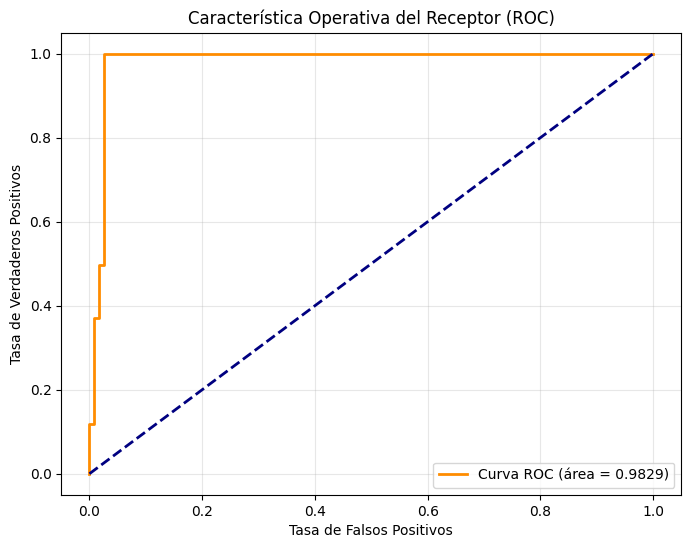

In [43]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob_cb) # Usando CatBoost
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Característica Operativa del Receptor (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**Análisis SHAP (Explicabilidad del Modelo)**

En el ámbito de la salud pública, la precisión algorítmica debe ir acompañada de la interpretabilidad clínica. Por ello, se implementó un análisis de Valores **SHAP (SHapley Additive exPlanations)** basado en la teoría de juegos cooperativos. Este método permite cuantificar la contribución exacta, positiva o negativa, de cada variable en la predicción de un caso individual. Esta visualización es fundamental para que el personal médico comprenda los factores específicos que elevan el riesgo de un paciente y pueda actuar de manera dirigida

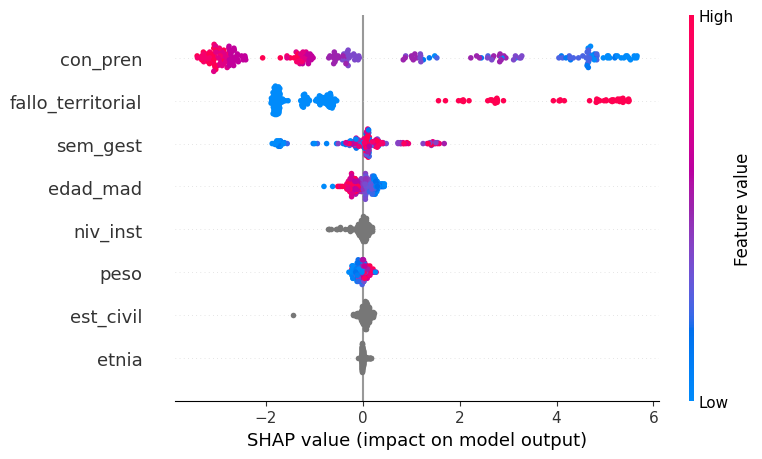

In [44]:
!pip install shap
import shap

explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_test_cat)

# Resumen de impacto de variables
shap.summary_plot(shap_values, X_test_cat)

**Interpretabilidad del Modelo mediante Valores SHAP**

Para mitigar el efecto de "caja negra" asociado a los modelos de Machine Learning de alta complejidad, se implementó un análisis de SHAP (SHapley Additive exPlanations). Esta herramienta, basada en la teoría de juegos, permite descomponer la contribución individual de cada variable sobre la probabilidad de que un óbito fetal sea clasificado como "Prevenible".

**Arquitectura del Gráfico de Resumen (Summary Plot)**

En la visualización presentada, cada punto representa una instancia del dataset. La posición en el Eje Y indica la importancia relativa de la variable (de mayor a menor impacto), mientras que el Eje X cuantifica el valor SHAP: un impacto positivo (derecha) incrementa la probabilidad de prevenibilidad, y un impacto negativo (izquierda) la disminuye. El gradiente de color identifica el valor real de la característica (rojo para valores altos y azul para valores bajos).

**Hallazgos Críticos y Evidencia del Modelo**
Del análisis de densidad de puntos se desprenden las siguientes observaciones clave:

* **Gestión Individual (con_pren):** Se consolida como el predictor más influyente. La concentración de puntos azules (pocos controles) en la zona de impacto positivo confirma que la deficiencia en el control prenatal es el principal detonante de la clase prevenible. Por el contrario, los puntos rojos (adecuado seguimiento) actúan como un factor protector que empuja la predicción hacia la clase no prevenible.

* **Logística y Acceso (gfallo_territorial):** El desplazamiento intercantonal para el fallecimiento (puntos rojos en valor 1) presenta un impacto SHAP positivo sistemático. Esto evidencia que el fallo en la capacidad resolutiva del territorio de residencia es un driver crítico de prevenibilidad.

* **Madurez Fetal (sem_gest, peso y talla):** Estas variables presentan un comportamiento coherente con la viabilidad biológica. Los valores altos (rojo) se asocian a una mayor probabilidad de prevenibilidad, lo que ratifica que el modelo identifica correctamente que los fetos con mayor madurez gestacional poseen un potencial de supervivencia que no fue garantizado por el sistema.

* **Determinantes Sociodemográficos**: Variables como la Edad de la Madre, la Etnia y el Nivel de Instrucción muestran distribuciones variables. Se observa que niveles de instrucción limitados y edades en extremos reproductivos tienden a desplazar la predicción hacia perfiles de vulnerabilidad, aunque con un peso menor que los factores de gestión directa.

**Conclusión de Explicabilidad**

En conclusión, el análisis SHAP confirma que el modelo CatBoost no solo es preciso, sino clínicamente coherente. La transparencia aportada por esta visualización garantiza que las decisiones de alerta temprana se fundamenten en los pilares de la gestión sanitaria (controles) y la equidad territorial, proporcionando una hoja de ruta clara para la intervención institucional.